# Data Visualization: Loan Approval Challenge

### Purpose
Explore the main drivers of loan approval (`Accept`) and turn them into modeling ideas.

### Scope
- Show approval and denial patterns.
- Check data quality in key fields.
- Flag strong signals and odd cases.

### Setup and Data Load

In [2]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame

df = pd.read_csv('../data/train.csv')
df.head(1)

,id,LoanNr_ChkDgt,Name,City,State,Bank,BankState,ApprovalDate,ApprovalFY,NoEmp,...,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementDate,DisbursementGross,BalanceGross,Accept
0,64afe857c28,9448323000,MIDWEST CRANKSHAFT & ENGINE,HARVEY,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,9-Aug-96,1996,28,...,0,0,1,0,N,N,31-Mar-97,"$600,000.00",$0.00,0


## 1) Baseline Class Distribution
Approval vs denial split in `Accept`.

        count  ratio_%
Accept                
1       16019    77.13
0        4749    22.87


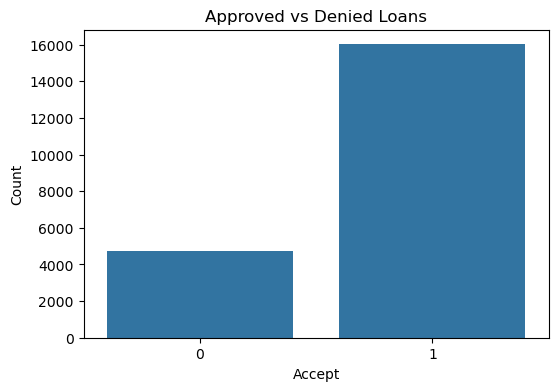

In [2]:
# What is the ratio of Approved vs. Denied loans?
import seaborn as sns
import matplotlib.pyplot as plt

counts = df['Accept'].value_counts(dropna=False)
ratios = df['Accept'].value_counts(normalize=True, dropna=False).mul(100).round(2)

summary = pd.DataFrame({'count': counts, 'ratio_%': ratios})
print(summary)

plt.figure(figsize=(6, 4))
sns.countplot(x='Accept', data=df)
plt.title('Approved vs Denied Loans')
plt.xlabel('Accept')
plt.ylabel('Count')
plt.show()

### Problem
- The dataset is clearly imbalanced toward approvals: roughly 16k approved vs about 4.8k denied (about 3.3:1).
- This means accuracy alone can be misleading; precision/recall, ROC-AUC, and threshold-sensitive metrics are more informative.
- The baseline approval prior should be reflected in train/validation splits and calibration decisions.

## 2) Business Maturity Signal (`NewExist`)
Compare approval outcomes for new businesses (`NewExist = 2`) and existing businesses (`NewExist = 1`).

Hypothesis: business maturity is a strong underwriting proxy and may interact with loan size and documentation fields.

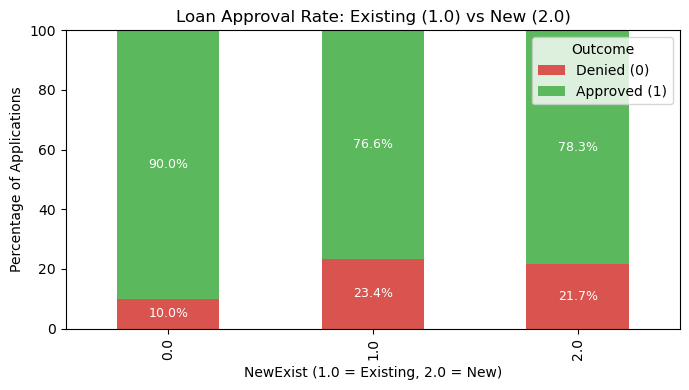

Accept,0,1
NewExist,,
0.0,10.000000,90.000000
1.0,23.416561,76.583439
2.0,21.712027,78.287973


In [3]:
# How does business maturity (NewExist) affect the outcome?
maturity_risk = (
    pd.crosstab(df['NewExist'], df['Accept'], normalize='index')
    .reindex(columns=[0, 1], fill_value=0)
    * 100
)

ax = maturity_risk.plot(
    kind='bar',
    stacked=True,
    color=['#d9534f', '#5cb85c'],
    figsize=(7, 4)
 )
ax.set_title('Loan Approval Rate: Existing (1.0) vs New (2.0)')
ax.set_xlabel('NewExist (1.0 = Existing, 2.0 = New)')
ax.set_ylabel('Percentage of Applications')
ax.set_ylim(0, 100)
ax.legend(['Denied (0)', 'Approved (1)'], title='Outcome', loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

maturity_risk

### Key Findings
- Existing businesses (`NewExist = 1`) show noticeably higher denial share than the `0` bucket and slightly higher than new businesses (`2`).
- The `NewExist = 0` group has unusually high approval in this run, suggesting it likely represents a special or noisy encoding group.
- `NewExist` is useful, but category cleaning and explicit handling of `0/unknown` values is essential before modeling.

### Data Quality Check for `NewExist`
Check uncommon `NewExist` values, especially `0.0`, and print the contingency table.

This is needed before using `NewExist` in modeling.

In [6]:
# Quick check: what is NewExist = 0.0?
newexist_counts = df['NewExist'].value_counts(dropna=False).sort_index()
newexist_pct = (df['NewExist'].value_counts(dropna=False, normalize=True).sort_index() * 100).round(2)

newexist_summary = pd.DataFrame({
    'count': newexist_counts,
    'percentage_%': newexist_pct
})

print('NewExist value counts and percentages:')
display(newexist_summary)

print('\nNewExist vs Accept crosstab:')
display(pd.crosstab(df['NewExist'], df['Accept']))

NewExist value counts and percentages:


,count,percentage_%
NewExist,,
0.0,10,0.05
1.0,14178,68.27
2.0,6577,31.67
NaN,3,0.01



NewExist vs Accept crosstab:


Accept,0,1
NewExist,,
0.0,1,9
1.0,3320,10858
2.0,1428,5149


## 3) Loan Size vs Outcome (`DisbursementGross`)
Check whether denial risk changes with loan amount.

Hypothesis: loan amounts span multiple orders of magnitude, so log-scale views and quantile bands are needed to see non-linear effects.

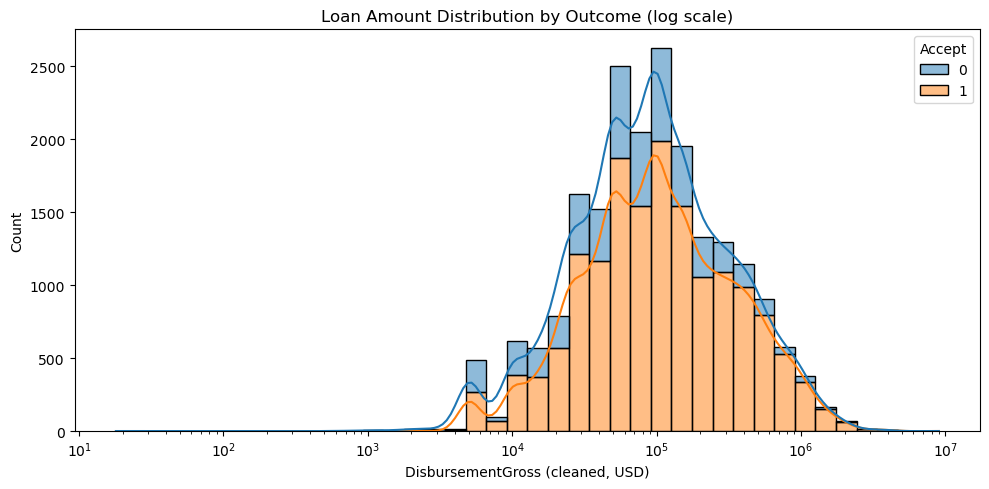

Top loan bands by denial rate:


,loan_band,applications,approval_rate,denial_rate
0,"(17.999, 20000.0]",2322,0.622308,0.377692
1,"(20000.0, 32886.8]",1832,0.740175,0.259825
2,"(50000.0, 66415.6]",1316,0.752280,0.247720
3,"(66415.6, 92964.0]",2077,0.753009,0.246991
4,"(92964.0, 116260.0]",2076,0.757707,0.242293


In [2]:
# Loan Size vs Risk: identify possible "danger zones" by loan amount
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Clean currency strings like "$123,456.00" into numeric values
df['DisbursementGross_cleaned'] = (
    df['DisbursementGross']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace({'': np.nan})
    .astype(float)
)

# Keep only rows with valid loan amount and outcome
plot_df = df.dropna(subset=['DisbursementGross_cleaned', 'Accept']).copy()
plot_df = plot_df[plot_df['DisbursementGross_cleaned'] > 0]

plt.figure(figsize=(10, 5))
sns.histplot(
    data=plot_df,
    x='DisbursementGross_cleaned',
    hue='Accept',
    multiple='stack',
    kde=True,
    log_scale=True,
    bins=40
)
plt.title('Loan Amount Distribution by Outcome (log scale)')
plt.xlabel('DisbursementGross (cleaned, USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Optional: quantify denial risk by amount bands
risk_by_band = (
    plot_df.assign(loan_band=pd.qcut(plot_df['DisbursementGross_cleaned'], q=10, duplicates='drop'))
    .groupby('loan_band', observed=False)['Accept']
    .agg(applications='size', approval_rate='mean')
    .assign(denial_rate=lambda x: 1 - x['approval_rate'])
    .sort_values('denial_rate', ascending=False)
    .reset_index()
)

print('Top loan bands by denial rate:')
display(risk_by_band.head(5))

### Key Findings
- Loan amounts are heavily right-skewed and spread over several orders of magnitude, validating the use of log-scale plots.
- The strongest denial concentration appears in lower loan-size bands (especially up to around 20k), then declines in higher bands.
- This indicates amount alone is not monotonic risk; interaction with firm profile/features is likely important.

### Data Audit for `DisbursementGross`
Audit non-numeric or non-positive loan amounts before analysis.

This keeps invalid monetary values out of the risk plots.

### Key Findings from Loan-Amount Bands
- Highest denial concentration appears in lower loan bands (especially up to around 20k in this run).
- The next low-amount band also shows elevated denial relative to mid/high bands.
- Most larger-amount quantile bands cluster around a tighter denial range, suggesting borrower profile features likely explain additional variance.

### Completeness Check for Loan Amount Field
Audit invalid `DisbursementGross` rows before filtering.

This shows how much data is removed from amount-based analysis.

In [8]:
# Audit DisbursementGross values before filtering with dropna
raw_disb = df['DisbursementGross']
cleaned_str = (
    raw_disb.astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
)
cleaned_num = pd.to_numeric(cleaned_str, errors='coerce')

audit = pd.DataFrame({
    'DisbursementGross_raw': raw_disb,
    'DisbursementGross_cleaned_str': cleaned_str,
    'DisbursementGross_cleaned_num': cleaned_num,
    'Accept': df['Accept']
})

# Invalid for analysis means missing/non-numeric/non-positive loan amount
invalid_mask = audit['DisbursementGross_cleaned_num'].isna() | (audit['DisbursementGross_cleaned_num'] <= 0)
invalid_rows = audit.loc[invalid_mask].copy()

print(f"Total rows: {len(audit):,}")
print(f"Invalid DisbursementGross rows: {len(invalid_rows):,}")
print(f"Invalid share: {len(invalid_rows) / len(audit):.2%}")

print('\nBreakdown of invalid reasons:')
reason_counts = pd.Series({
    'missing_or_non_numeric': int(audit['DisbursementGross_cleaned_num'].isna().sum()),
    'non_positive_value': int((audit['DisbursementGross_cleaned_num'] <= 0).sum())
})
display(reason_counts.to_frame('count'))

print('\nSample invalid rows (up to 25):')
display(invalid_rows.head(25))

# If you want to inspect all invalid rows, uncomment:
# display(invalid_rows)

Total rows: 20,768
Invalid DisbursementGross rows: 1
Invalid share: 0.00%

Breakdown of invalid reasons:


,count
missing_or_non_numeric,0
non_positive_value,1



Sample invalid rows (up to 25):


,DisbursementGross_raw,DisbursementGross_cleaned_str,DisbursementGross_cleaned_num,Accept
11414,$0.00,0.00,0.0,0


## 4) Capital Intensity Signal (Loan per Employee)
Feature: `loan_per_employee = DisbursementGross / NoEmp`.

Large requested amounts relative to headcount may indicate elevated repayment risk or atypical applications.

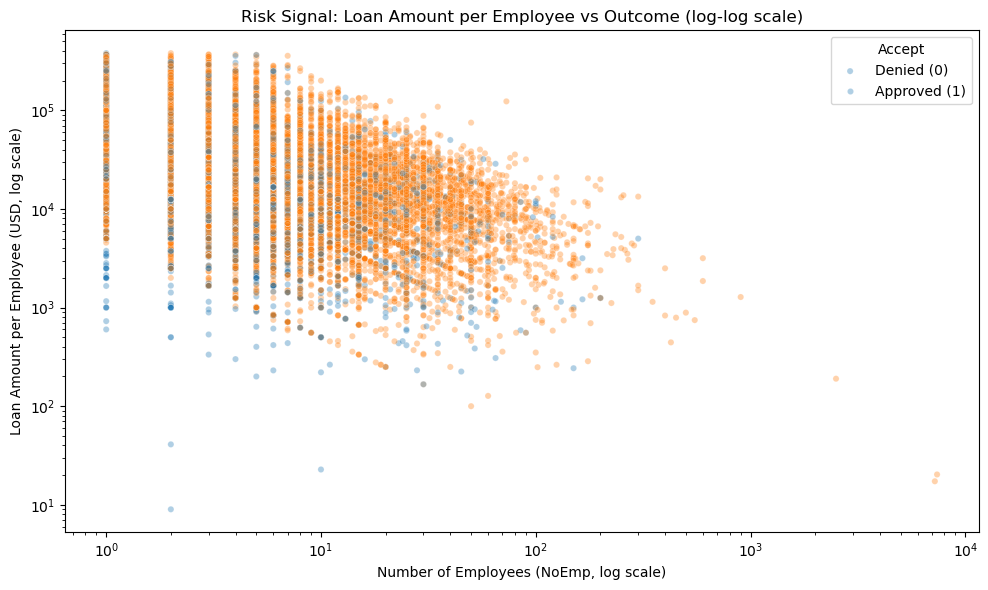

Top efficiency bands by denial rate:


,eff_band,applications,approval_rate,denial_rate
0,"(8.999, 4330.476]",2056,0.717899,0.282101
1,"(4330.476, 7500.0]",2187,0.734339,0.265661
2,"(20000.0, 25000.0]",1809,0.765616,0.234384
3,"(7500.0, 10700.2]",1924,0.776507,0.223493
4,"(85000.0, 3520000.0]",2039,0.781756,0.218244


Correlation(loan_per_employee, Accept): 0.0281 (negative means higher ratio -> lower approval)


In [10]:
# Does a high loan amount relative to number of employees signal risk?
# Build a stable metric: dollars requested per employee.
analysis_df = df.dropna(subset=['NoEmp', 'DisbursementGross_cleaned', 'Accept']).copy()
analysis_df = analysis_df[(analysis_df['NoEmp'] > 0) & (analysis_df['DisbursementGross_cleaned'] > 0)]

analysis_df['loan_per_employee'] = analysis_df['DisbursementGross_cleaned'] / analysis_df['NoEmp']

# Keep extreme outliers from dominating the chart while preserving most observations.
p99 = analysis_df['loan_per_employee'].quantile(0.99)
plot_df_eff = analysis_df[analysis_df['loan_per_employee'] <= p99].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df_eff,
    x='NoEmp',
    y='loan_per_employee',
    hue='Accept',
    alpha=0.35,
    s=20
)
plt.xscale('log')
plt.yscale('log')
plt.title('Risk Signal: Loan Amount per Employee vs Outcome (log-log scale)')
plt.xlabel('Number of Employees (NoEmp, log scale)')
plt.ylabel('Loan Amount per Employee (USD, log scale)')
plt.legend(title='Accept', labels=['Denied (0)', 'Approved (1)'])
plt.tight_layout()
plt.show()

# Quantify risk by loan-per-employee deciles (higher decile = larger amount per employee).
risk_by_eff_band = (
    analysis_df.assign(eff_band=pd.qcut(analysis_df['loan_per_employee'], q=10, duplicates='drop'))
    .groupby('eff_band', observed=False)['Accept']
    .agg(applications='size', approval_rate='mean')
    .assign(denial_rate=lambda x: 1 - x['approval_rate'])
    .sort_values('denial_rate', ascending=False)
    .reset_index()
)

print('Top efficiency bands by denial rate:')
display(risk_by_eff_band.head(5))

# Correlation check (point-biserial equivalent through binary encoding).
corr = analysis_df[['loan_per_employee', 'Accept']].corr().iloc[0, 1]
print(f"Correlation(loan_per_employee, Accept): {corr:.4f} (negative means higher ratio -> lower approval)")

### Key Findings
- The loan-per-employee feature captures a broad separation structure and highlights extreme applications with very high capital intensity.
- The visual trend suggests risk concentration among extreme ratios, making this a strong candidate engineered feature.
- Outlier-aware transforms (for example, `log1p`, clipping, or robust scaling) should be considered before model training.

### Outlier Spotlight
Show the most extreme loan-per-employee observations and label the top outliers.

Use this to decide whether clipping or robust scaling is needed.

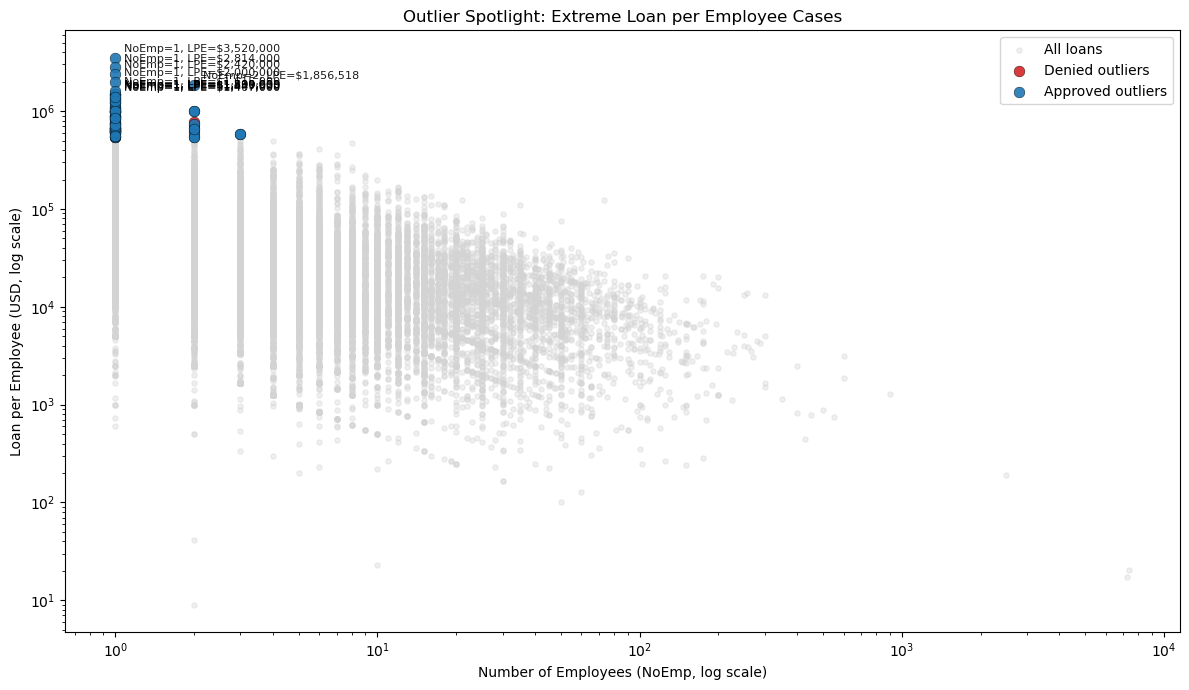

Outlier threshold (99.5th percentile): $550,000.00
Outliers shown: 107 of 20,555 rows (0.52%)


,NoEmp,DisbursementGross_cleaned,loan_per_employee,Accept
1587,1,3520000.0,3520000.0,1
5240,1,2814000.0,2814000.0,1
11332,1,2420000.0,2420000.0,1
14332,1,2000000.0,2000000.0,1
2642,2,3713037.0,1856518.5,1
16868,1,1615000.0,1615000.0,1
6432,1,1500000.0,1500000.0,1
11269,1,1500000.0,1500000.0,1
10736,1,1499000.0,1499000.0,1
3806,1,1479925.0,1479925.0,1


In [11]:
# Outlier spotlight: keep all points and make extreme loan-per-employee cases pop out
outlier_df = df.dropna(subset=['NoEmp', 'DisbursementGross_cleaned', 'Accept']).copy()
outlier_df = outlier_df[(outlier_df['NoEmp'] > 0) & (outlier_df['DisbursementGross_cleaned'] > 0)]
outlier_df['loan_per_employee'] = outlier_df['DisbursementGross_cleaned'] / outlier_df['NoEmp']

# Define outliers using a very high percentile so only the most extreme cases are highlighted
p995 = outlier_df['loan_per_employee'].quantile(0.995)
outliers = outlier_df[outlier_df['loan_per_employee'] >= p995].copy()

top_n = 12
top_outliers = outliers.nlargest(top_n, 'loan_per_employee').copy()

plt.figure(figsize=(12, 7))

# Background: all observations
plt.scatter(
    outlier_df['NoEmp'],
    outlier_df['loan_per_employee'],
    c='lightgray',
    alpha=0.35,
    s=14,
    label='All loans'
)

# Foreground: extreme outliers
palette = {0: '#d62728', 1: '#1f77b4'}
for val, label in [(0, 'Denied outliers'), (1, 'Approved outliers')]:
    d = outliers[outliers['Accept'] == val]
    if len(d) > 0:
        plt.scatter(
            d['NoEmp'],
            d['loan_per_employee'],
            c=palette[val],
            alpha=0.9,
            s=60,
            edgecolors='black',
            linewidths=0.3,
            label=label
        )

# Label the most extreme points so they are easy to inspect
for _, r in top_outliers.iterrows():
    plt.annotate(
        f"NoEmp={int(r['NoEmp'])}, LPE=${r['loan_per_employee']:,.0f}",
        (r['NoEmp'], r['loan_per_employee']),
        xytext=(6, 4),
        textcoords='offset points',
        fontsize=8,
        alpha=0.9
    )

plt.xscale('log')
plt.yscale('log')
plt.title('Outlier Spotlight: Extreme Loan per Employee Cases')
plt.xlabel('Number of Employees (NoEmp, log scale)')
plt.ylabel('Loan per Employee (USD, log scale)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Outlier threshold (99.5th percentile): ${p995:,.2f}")
print(f"Outliers shown: {len(outliers):,} of {len(outlier_df):,} rows ({len(outliers)/len(outlier_df):.2%})")

display(top_outliers[['NoEmp', 'DisbursementGross_cleaned', 'loan_per_employee', 'Accept']].head(top_n))

### Data Quality Audit for `NoEmp`
Check missing and non-positive employee counts, then summarize valid values.

`NoEmp` is a core feature, so it needs a quality check.

In [4]:
# NoEmp audit: counts, percentages, missing values, and invalid values
noemp_raw = df['NoEmp']

# Convert to numeric safely to catch unexpected text values as invalid
noemp_num = pd.to_numeric(noemp_raw, errors='coerce')

total_rows = len(noemp_raw)
missing_mask = noemp_raw.isna()
non_numeric_mask = noemp_raw.notna() & noemp_num.isna()
non_positive_mask = noemp_num.notna() & (noemp_num <= 0)
invalid_mask_noemp = missing_mask | non_numeric_mask | non_positive_mask

# Summary counts and percentages
summary_noemp = pd.DataFrame({
    'count': [
        total_rows,
        int(missing_mask.sum()),
        int(non_numeric_mask.sum()),
        int(non_positive_mask.sum()),
        int(invalid_mask_noemp.sum()),
        int((~invalid_mask_noemp).sum())
    ]
}, index=[
    'total_rows',
    'missing',
    'non_numeric',
    'non_positive (<=0)',
    'invalid_total',
    'valid_rows'
])
summary_noemp['percentage_%'] = (summary_noemp['count'] / total_rows * 100).round(2)

print('NoEmp data quality summary:')
display(summary_noemp)

# Value distribution for valid numeric values (top 20 most common)
valid_noemp = noemp_num[~invalid_mask_noemp]
value_counts = valid_noemp.value_counts(dropna=False).sort_values(ascending=False)
value_percent = (value_counts / total_rows * 100).round(2)
noemp_distribution = pd.DataFrame({
    'NoEmp': value_counts.index,
    'count': value_counts.values,
    'percentage_of_total_%': value_percent.values
})

print('\nTop 20 most frequent NoEmp values (valid only):')
display(noemp_distribution.head(20))

# Additional descriptive stats for valid values
print('\nDescriptive stats for valid NoEmp values:')
display(valid_noemp.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame('NoEmp'))

# Show sample invalid rows for inspection
invalid_noemp_rows = df.loc[invalid_mask_noemp, ['NoEmp', 'Accept']].copy()
print('\nSample invalid NoEmp rows (up to 20):')
display(invalid_noemp_rows.head(20))

NoEmp data quality summary:


,count,percentage_%
total_rows,20768,100.00
missing,0,0.00
non_numeric,0,0.00
non_positive (<=0),212,1.02
invalid_total,212,1.02
valid_rows,20556,98.98



Top 20 most frequent NoEmp values (valid only):


,NoEmp,count,percentage_of_total_%
0,1,3460,16.66
1,2,3320,15.99
2,3,2206,10.62
3,4,1840,8.86
4,5,1462,7.04
5,6,1052,5.07
6,10,753,3.63
7,8,710,3.42
8,7,672,3.24
9,12,473,2.28



Descriptive stats for valid NoEmp values:


,NoEmp
count,20556.000000
mean,10.895408
std,77.045620
min,1.000000
1%,1.000000
5%,1.000000
25%,2.000000
50%,4.000000
75%,10.000000
95%,38.000000



Sample invalid NoEmp rows (up to 20):


,NoEmp,Accept
70,0,1
160,0,1
239,0,1
260,0,0
358,0,1
394,0,1
414,0,1
586,0,1
740,0,0
796,0,1


### Company Size Bands vs Outcome
Group applications by employee-count bands and compare denial rates.

Size bands give a simple risk gradient that is easy to explain.

Approval/Denial by NoEmp bands:


,NoEmp_band,applications,share_of_total_%,approval_rate_%,denial_rate_%
0,1,3460,16.83,70.87,29.13
1,2-5,8828,42.95,73.83,26.17
2,6-10,3553,17.28,78.41,21.59
3,11-50,4132,20.10,86.30,13.70
4,>50,583,2.84,91.77,8.23


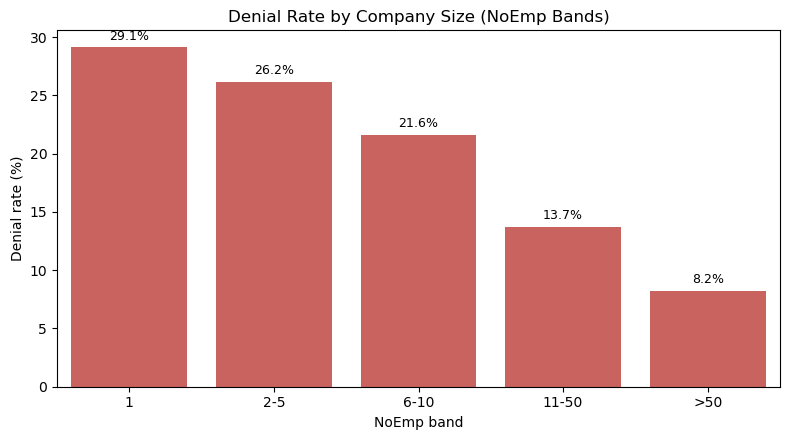

Highest denial band: 1 (29.13%) | Lowest denial band: >50 (8.23%)


In [5]:
# Approval rate by NoEmp bands: (1), (2-5), (6-10), (11-50), (>50)
noemp_band_df = df[['NoEmp', 'Accept']].copy()
noemp_band_df['NoEmp_num'] = pd.to_numeric(noemp_band_df['NoEmp'], errors='coerce')

# Keep only valid rows for this analysis
noemp_band_df = noemp_band_df[
    noemp_band_df['NoEmp_num'].notna()
    & (noemp_band_df['NoEmp_num'] > 0)
    & noemp_band_df['Accept'].notna()
].copy()

bins = [0, 1, 5, 10, 50, np.inf]
labels = ['1', '2-5', '6-10', '11-50', '>50']
noemp_band_df['NoEmp_band'] = pd.cut(noemp_band_df['NoEmp_num'], bins=bins, labels=labels, right=True)

band_summary = (
    noemp_band_df
    .groupby('NoEmp_band', observed=False)['Accept']
    .agg(applications='size', approval_rate='mean')
    .assign(denial_rate=lambda x: 1 - x['approval_rate'])
    .reset_index()
)

band_summary['approval_rate_%'] = (band_summary['approval_rate'] * 100).round(2)
band_summary['denial_rate_%'] = (band_summary['denial_rate'] * 100).round(2)
band_summary['share_of_total_%'] = (band_summary['applications'] / band_summary['applications'].sum() * 100).round(2)

print('Approval/Denial by NoEmp bands:')
display(band_summary[['NoEmp_band', 'applications', 'share_of_total_%', 'approval_rate_%', 'denial_rate_%']])

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(data=band_summary, x='NoEmp_band', y='denial_rate_%', color='#d9534f')
ax.set_title('Denial Rate by Company Size (NoEmp Bands)')
ax.set_xlabel('NoEmp band')
ax.set_ylabel('Denial rate (%)')

for i, v in enumerate(band_summary['denial_rate_%']):
    ax.text(i, v + 0.4, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Simple risk signal note
highest_risk = band_summary.sort_values('denial_rate_%', ascending=False).iloc[0]
lowest_risk = band_summary.sort_values('denial_rate_%', ascending=True).iloc[0]
print(
    f"Highest denial band: {highest_risk['NoEmp_band']} ({highest_risk['denial_rate_%']:.2f}%) | "
    f"Lowest denial band: {lowest_risk['NoEmp_band']} ({lowest_risk['denial_rate_%']:.2f}%)"
)

### Key Findings
- Denial risk declines almost monotonically as company size increases.
- In this run: `NoEmp = 1` has the highest denial rate (about 29%), while `>50` employees has the lowest (about 8%).
- Company size is one of the clearest interpretable risk signals in the notebook and should be preserved in feature engineering.

## 5) Program Flags: `LowDoc` and `RevLineCr`
Compare approval rates across the `LowDoc` and `RevLineCr` flags.

These fields carry signal, but they also contain noisy category variants.

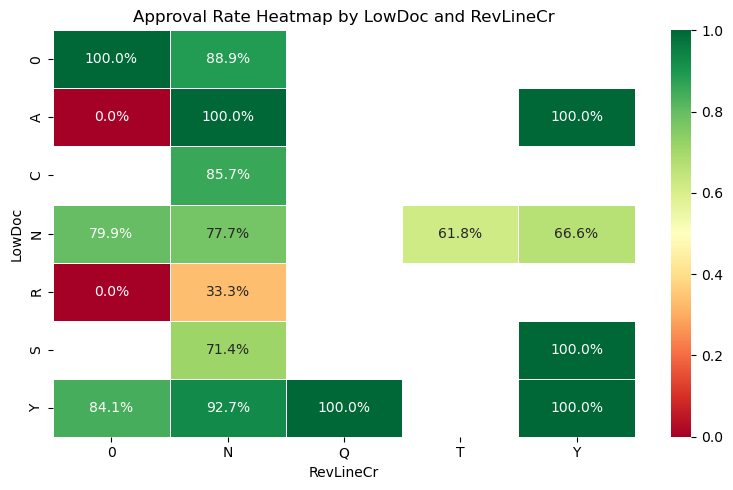

Approval rates table (%):


RevLineCr,0,N,Q,T,Y
LowDoc,,,,,
0,100.00,88.89,NaN,NaN,NaN
A,0.00,100.00,NaN,NaN,100.00
C,NaN,85.71,NaN,NaN,NaN
N,79.95,77.68,NaN,61.79,66.58
R,0.00,33.33,NaN,NaN,NaN
S,NaN,71.43,NaN,NaN,100.00
Y,84.07,92.74,100.0,NaN,100.00


In [6]:
# Approval rate by loan "program" dimensions: LowDoc x RevLineCr
analysis_cols = ['LowDoc', 'RevLineCr', 'Accept']
program_df = df[analysis_cols].dropna().copy()

# Normalize category text to avoid duplicate buckets caused by casing/spaces
program_df['LowDoc'] = program_df['LowDoc'].astype(str).str.strip().str.upper()
program_df['RevLineCr'] = program_df['RevLineCr'].astype(str).str.strip().str.upper()

pivot = program_df.pivot_table(
    index='LowDoc',
    columns='RevLineCr',
    values='Accept',
    aggfunc='mean'
).sort_index().sort_index(axis=1)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1%',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor='white'
 )
plt.title('Approval Rate Heatmap by LowDoc and RevLineCr')
plt.xlabel('RevLineCr')
plt.ylabel('LowDoc')
plt.tight_layout()
plt.show()

print('Approval rates table (%):')
display((pivot * 100).round(2))

### Key Findings
- `LowDoc` and `RevLineCr` combinations show strong variation in approval rate.
- However, the heatmap includes multiple non-standard categories (`0`, `A`, `C`, `R`, `Q`, `T`, etc.), which can create unstable tiny-group percentages.
- The reliable takeaway is signal presence, not exact percentages for rare categories; canonicalization to `Y/N/Unknown` is recommended.

### Data Quality Audit for `LowDoc`
Check missing and invalid `LowDoc` values beyond the expected `Y/N` categories.

This avoids mixing noisy values into the heatmap.

In [7]:
# LowDoc audit: counts, percentages, missing values, and invalid categories
lowdoc_raw = df['LowDoc']

# Standardize to string for consistent category checks
lowdoc_std = lowdoc_raw.astype('string').str.strip().str.upper()

# Missing includes true NaN and blank strings
missing_mask_lowdoc = lowdoc_raw.isna() | lowdoc_std.isna() | (lowdoc_std == '')

# Canonical valid labels for this flag
valid_values = {'Y', 'N'}
valid_mask_lowdoc = lowdoc_std.isin(valid_values)
invalid_mask_lowdoc = (~missing_mask_lowdoc) & (~valid_mask_lowdoc)

total_rows = len(df)
summary_lowdoc = pd.DataFrame(
    {'count': [
        total_rows,
        int(missing_mask_lowdoc.sum()),
        int(invalid_mask_lowdoc.sum()),
        int(valid_mask_lowdoc.sum())
    ]},
    index=['total_rows', 'missing', 'invalid_non_YN', 'valid_YN']
)
summary_lowdoc['percentage_%'] = (summary_lowdoc['count'] / total_rows * 100).round(2)

print('LowDoc data quality summary:')
display(summary_lowdoc)

# Full distribution (including missing shown as MISSING)
lowdoc_distribution = (
    lowdoc_std.fillna('MISSING')
    .replace({'': 'MISSING'})
    .value_counts(dropna=False)
    .rename_axis('LowDoc_value')
    .to_frame('count')
)
lowdoc_distribution['percentage_%'] = (lowdoc_distribution['count'] / total_rows * 100).round(2)

print('\nLowDoc value distribution (all categories):')
display(lowdoc_distribution)

print('\nSample invalid LowDoc rows (up to 20):')
display(df.loc[invalid_mask_lowdoc, ['LowDoc', 'RevLineCr', 'Accept']].head(20))

LowDoc data quality summary:


,count,percentage_%
total_rows,20768,100.00
missing,36,0.17
invalid_non_YN,51,0.25
valid_YN,20681,99.58



LowDoc value distribution (all categories):


,count,percentage_%
LowDoc_value,,
N,16903,81.39
Y,3778,18.19
MISSING,36,0.17
0,26,0.13
S,8,0.04
C,7,0.03
A,6,0.03
R,4,0.02



Sample invalid LowDoc rows (up to 20):


,LowDoc,RevLineCr,Accept
56,S,N,1
394,S,N,1
412,0,NaN,1
1413,R,N,0
1949,0,NaN,1
1959,S,N,1
2225,C,N,1
2555,0,N,1
2994,0,N,1
3779,A,Y,1


### Data Quality Audit for `RevLineCr`
Check `RevLineCr` for missing and invalid values beyond the expected `Y/N` categories.

This keeps category noise from distorting the results.

In [8]:
# RevLineCr audit: counts, percentages, missing values, and invalid categories
revline_raw = df['RevLineCr']

# Standardize to string for consistent category checks
revline_std = revline_raw.astype('string').str.strip().str.upper()

# Missing includes true NaN and blank strings
missing_mask_revline = revline_raw.isna() | revline_std.isna() | (revline_std == '')

# Canonical valid labels for this flag
valid_values_revline = {'Y', 'N'}
valid_mask_revline = revline_std.isin(valid_values_revline)
invalid_mask_revline = (~missing_mask_revline) & (~valid_mask_revline)

total_rows = len(df)
summary_revline = pd.DataFrame(
    {'count': [
        total_rows,
        int(missing_mask_revline.sum()),
        int(invalid_mask_revline.sum()),
        int(valid_mask_revline.sum())
    ]},
    index=['total_rows', 'missing', 'invalid_non_YN', 'valid_YN']
)
summary_revline['percentage_%'] = (summary_revline['count'] / total_rows * 100).round(2)

print('RevLineCr data quality summary:')
display(summary_revline)

# Full distribution (including missing shown as MISSING)
revline_distribution = (
    revline_std.fillna('MISSING')
    .replace({'': 'MISSING'})
    .value_counts(dropna=False)
    .rename_axis('RevLineCr_value')
    .to_frame('count')
)
revline_distribution['percentage_%'] = (revline_distribution['count'] / total_rows * 100).round(2)

print('\nRevLineCr value distribution (all categories):')
display(revline_distribution)

print('\nSample invalid RevLineCr rows (up to 20):')
display(df.loc[invalid_mask_revline, ['RevLineCr', 'LowDoc', 'Accept']].head(20))

RevLineCr data quality summary:


,count,percentage_%
total_rows,20768,100.00
missing,126,0.61
invalid_non_YN,5328,25.65
valid_YN,15314,73.74



RevLineCr value distribution (all categories):


,count,percentage_%
RevLineCr_value,,
N,10037,48.33
Y,5277,25.41
0,5046,24.3
T,281,1.35
MISSING,126,0.61
Q,1,0.0



Sample invalid RevLineCr rows (up to 20):


,RevLineCr,LowDoc,Accept
5,0,Y,0
9,0,N,1
11,0,N,1
13,0,N,1
16,0,N,1
17,0,N,1
24,0,Y,0
25,0,N,1
28,0,N,0
30,0,N,1


## 6) Bank-Level Behavior Audit
Check whether bank groups appear more permissive or conservative.

Bank-level effects can reflect institutional policy differences.

In [ ]:
# Bank-level approval behavior and missing-bank audit
bank_col = 'Bank' if 'Bank' in df.columns else 'Name'

bank_df = df[[bank_col, 'Accept']].copy()
bank_df['Accept'] = pd.to_numeric(bank_df['Accept'], errors='coerce')
bank_df = bank_df[bank_df['Accept'].isin([0, 1])].copy()

bank_df['BankClean'] = (
    bank_df[bank_col]
    .astype('string')
    .str.strip()
    .str.upper()
)
bank_df['BankClean'] = bank_df['BankClean'].replace({'': pd.NA}).fillna('MISSING')

bank_summary = (
    bank_df.groupby('BankClean', dropna=False)['Accept']
    .agg(applications='size', approval_rate='mean')
    .assign(
        denial_rate=lambda x: 1 - x['approval_rate'],
        approvals=lambda x: (x['applications'] * x['approval_rate']).round().astype(int)
    )
    .sort_values(['applications', 'approval_rate'], ascending=[False, False])
)

print(f"Rows used: {len(bank_df):,}")
print(f"Unique bank labels (including MISSING): {bank_summary.shape[0]:,}")

stable = bank_summary[bank_summary['applications'] >= 50].copy()

print('\nTop banks by approval rate (min 50 applications):')
display(stable.sort_values('approval_rate', ascending=False).head(10))

print('\nTop banks by denial rate (min 50 applications):')
display(stable.sort_values('denial_rate', ascending=False).head(10))

missing_bank = bank_df[bank_df['BankClean'] == 'MISSING']
missing_total = len(missing_bank)
missing_approved = int((missing_bank['Accept'] == 1).sum())
missing_denied = int((missing_bank['Accept'] == 0).sum())

print('\nMissing-bank rows summary:')
print(f"MISSING rows: {missing_total:,}")
print(f"Approved among MISSING: {missing_approved:,}")
print(f"Denied among MISSING: {missing_denied:,}")
if missing_total > 0:
    print(f"Approval rate for MISSING bank rows: {missing_approved / missing_total:.2%}")

# Visualize the most frequent banks to avoid tiny-sample distortion
top_volume = stable.sort_values('applications', ascending=False).head(15).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_volume, x='approval_rate', y='BankClean', color='#4c78a8')
plt.title('Approval Rate by Top-Volume Banks (min 50 applications)')
plt.xlabel('Approval rate')
plt.ylabel('Bank')
plt.xlim(0, 1)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.show()

### Key Findings
- Bank-level approval rates vary substantially, indicating lender-specific behavior is present.
- Small-sample banks can appear extreme, so interpretation should be restricted to groups above a minimum volume.
- Missing-bank records should be tracked explicitly because they may represent a non-random slice of the dataset.

### Missing Bank Values Check
Measure how often bank identifiers are missing and whether those rows behave differently.

Missing bank names may point to data quality issues or a distinct subset of applications.

## 7) Timeline Consistency: Approval vs Disbursement Dates
Build `Disbursement_Delay = DisbursementDate - ApprovalDate` and compare delays by outcome.

Timing fields can show process anomalies, delays, or data-entry issues.

C:\Users\nyliz\AppData\Local\Temp\ipykernel_18180\907499659.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  plot_df["ApprovalDate"] = pd.to_datetime(plot_df["ApprovalDate"], errors="coerce")
C:\Users\nyliz\AppData\Local\Temp\ipykernel_18180\907499659.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  plot_df["DisbursementDate"] = pd.to_datetime(plot_df["DisbursementDate"], errors="coerce")


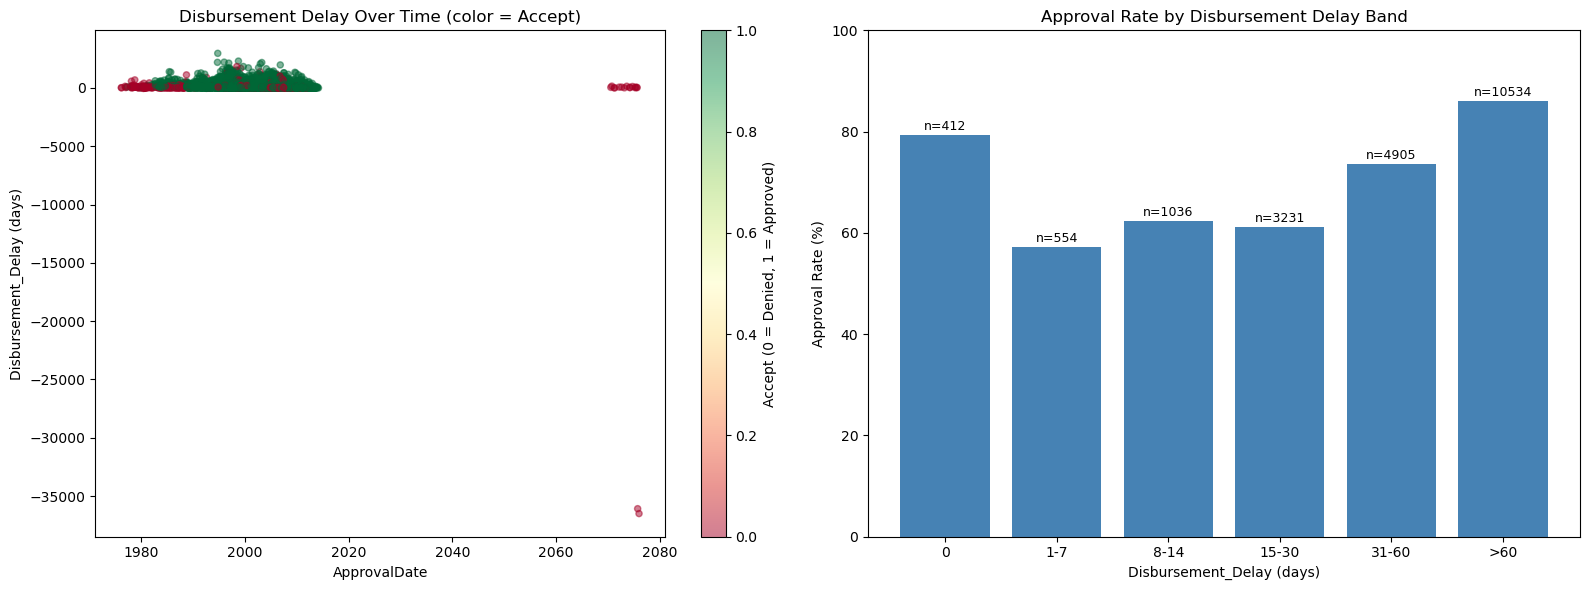

Rows used for plot: 20684
Average disbursement delay (days) by Accept:
Accept
0     56.32
1    128.34
Name: Disbursement_Delay, dtype: float64


In [12]:
# Relationship between Accept, ApprovalDate and DisbursementDate
plot_df = df[["ApprovalDate", "DisbursementDate", "Accept"]].copy()

plot_df["ApprovalDate"] = pd.to_datetime(plot_df["ApprovalDate"], errors="coerce")
plot_df["DisbursementDate"] = pd.to_datetime(plot_df["DisbursementDate"], errors="coerce")
plot_df["Disbursement_Delay"] = (
    plot_df["DisbursementDate"] - plot_df["ApprovalDate"]
).dt.days

# Keep valid rows only
plot_df = plot_df.dropna(subset=["ApprovalDate", "Disbursement_Delay", "Accept"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1) Delay over approval time, colored by accepted status
scatter = axes[0].scatter(
    plot_df["ApprovalDate"],
    plot_df["Disbursement_Delay"],
    c=plot_df["Accept"],
    cmap="RdYlGn",
    alpha=0.5,
    s=20,
)
axes[0].set_title("Disbursement Delay Over Time (color = Accept)")
axes[0].set_xlabel("ApprovalDate")
axes[0].set_ylabel("Disbursement_Delay (days)")
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label("Accept (0 = Denied, 1 = Approved)")

# 2) Approval rate by delay band
max_delay = int(plot_df["Disbursement_Delay"].max())
upper_bin = max(61, max_delay + 1)
delay_bins = [-1, 0, 7, 14, 30, 60, upper_bin]
band_labels = ["0", "1-7", "8-14", "15-30", "31-60", ">60"]

plot_df["Delay_Band"] = pd.cut(
    plot_df["Disbursement_Delay"],
    bins=delay_bins,
    labels=band_labels,
    include_lowest=True
)

band_summary = (
    plot_df.groupby("Delay_Band", observed=False)["Accept"]
    .agg(["mean", "count"])
    .reset_index()
)
band_summary["approval_rate_pct"] = band_summary["mean"] * 100

axes[1].bar(
    band_summary["Delay_Band"].astype(str),
    band_summary["approval_rate_pct"],
    color="steelblue"
)
axes[1].set_title("Approval Rate by Disbursement Delay Band")
axes[1].set_xlabel("Disbursement_Delay (days)")
axes[1].set_ylabel("Approval Rate (%)")
axes[1].set_ylim(0, 100)

for i, row in band_summary.iterrows():
    if pd.notna(row["approval_rate_pct"]):
        axes[1].text(i, row["approval_rate_pct"] + 1, f"n={int(row['count'])}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("Rows used for plot:", len(plot_df))
print("Average disbursement delay (days) by Accept:")
print(plot_df.groupby("Accept")["Disbursement_Delay"].mean().round(2))

### Key Findings
- Delay behavior is non-linear: approvals dip for short delays (`1-30` days) and rebound for longer delays (`31+` days) in this run.
- The timeline plot reveals clear anomalies (extreme negative delays and far-future dates), indicating date-quality issues.
- Temporal features should be built with robust cleaning rules (invalid-date handling, clipping, and anomaly flags).

### Approval Date Availability Sanity Check
Compare records with and without parseable `ApprovalDate`.

If denied cases still have approval dates, the field may represent a process step rather than final acceptance.

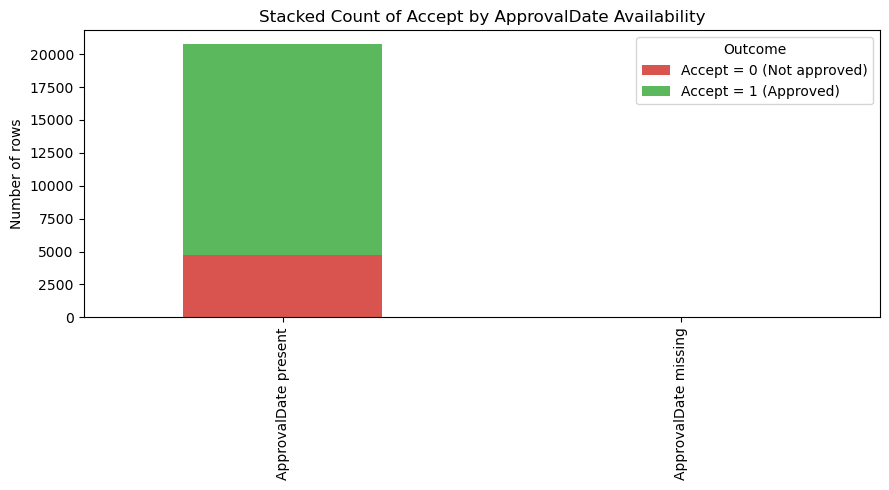

Denied rows with an ApprovalDate: 4,749
Total denied rows: 4,749
Share of denied rows that still have ApprovalDate: 100.00%

Sample denied rows that still have ApprovalDate:


,ApprovalDate,ApprovalDate_parsed,Accept
0,9-Aug-96,1996-08-09,0
4,3-May-07,2007-05-03,0
5,11-Mar-03,2003-03-11,0
10,31-Mar-03,2003-03-31,0
15,1-Apr-08,2008-04-01,0
21,4-Oct-06,2006-10-04,0
24,17-Sep-02,2002-09-17,0
28,21-May-02,2002-05-21,0
34,7-Nov-06,2006-11-07,0
36,15-Aug-05,2005-08-15,0


In [13]:
# Stacked view: Accept (0/1) by whether ApprovalDate exists
approval_check = df[["ApprovalDate", "Accept"]].copy()

# Parse dates robustly (mixed formats allowed)
approval_check["ApprovalDate_parsed"] = pd.to_datetime(
    approval_check["ApprovalDate"], errors="coerce", format="mixed"
)
approval_check["HasApprovalDate"] = approval_check["ApprovalDate_parsed"].notna()
approval_check["HasApprovalDate"] = approval_check["HasApprovalDate"].map(
    {True: "ApprovalDate present", False: "ApprovalDate missing"}
)

stack_counts = (
    approval_check.groupby(["HasApprovalDate", "Accept"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(index=["ApprovalDate present", "ApprovalDate missing"], fill_value=0)
)

# Ensure both classes appear in legend/order
for col in [0, 1]:
    if col not in stack_counts.columns:
        stack_counts[col] = 0
stack_counts = stack_counts[[0, 1]]

ax = stack_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    color=["#d9534f", "#5cb85c"]
)
ax.set_title("Stacked Count of Accept by ApprovalDate Availability")
ax.set_xlabel("")
ax.set_ylabel("Number of rows")
ax.legend(["Accept = 0 (Not approved)", "Accept = 1 (Approved)"], title="Outcome")
plt.tight_layout()
plt.show()

# Answer your exact question: rows denied but still having ApprovalDate
denied_with_date = approval_check[
    (approval_check["Accept"] == 0) & (approval_check["ApprovalDate_parsed"].notna())
].copy()

print(f"Denied rows with an ApprovalDate: {len(denied_with_date):,}")
print(f"Total denied rows: {(approval_check['Accept'] == 0).sum():,}")
if (approval_check['Accept'] == 0).sum() > 0:
    pct = len(denied_with_date) / (approval_check['Accept'] == 0).sum() * 100
    print(f"Share of denied rows that still have ApprovalDate: {pct:.2f}%")

print("\nSample denied rows that still have ApprovalDate:")
display(
    denied_with_date[["ApprovalDate", "ApprovalDate_parsed", "Accept"]].head(10)
)

### Key Findings
- A non-trivial subset of denied records still has parseable `ApprovalDate`, indicating date fields may reflect process milestones rather than final acceptance.
- This supports using date-derived anomaly flags instead of trusting raw temporal fields at face value.
- Any model using date features should include robust missingness and inconsistency indicators.

## 8) Jobs and Workforce Dynamics
Study `RetainedJob` together with `NoEmp` and loan outcome.

Employment variables can capture business stability and expected loan impact.

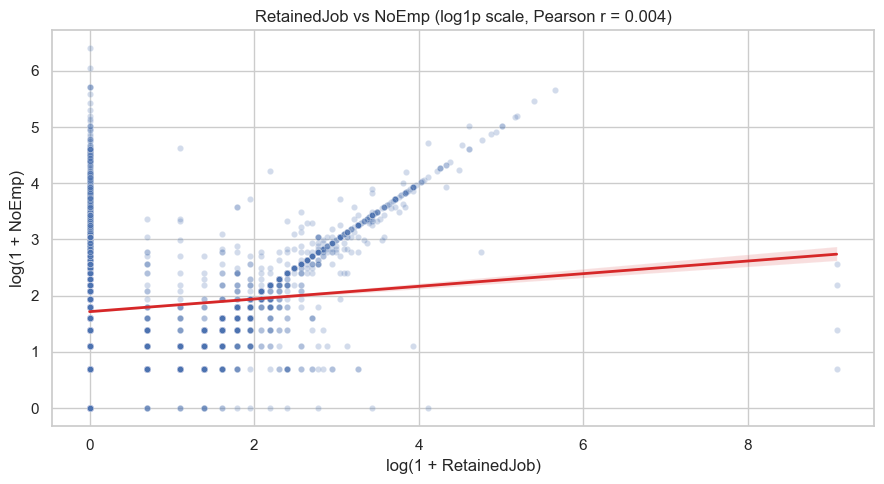

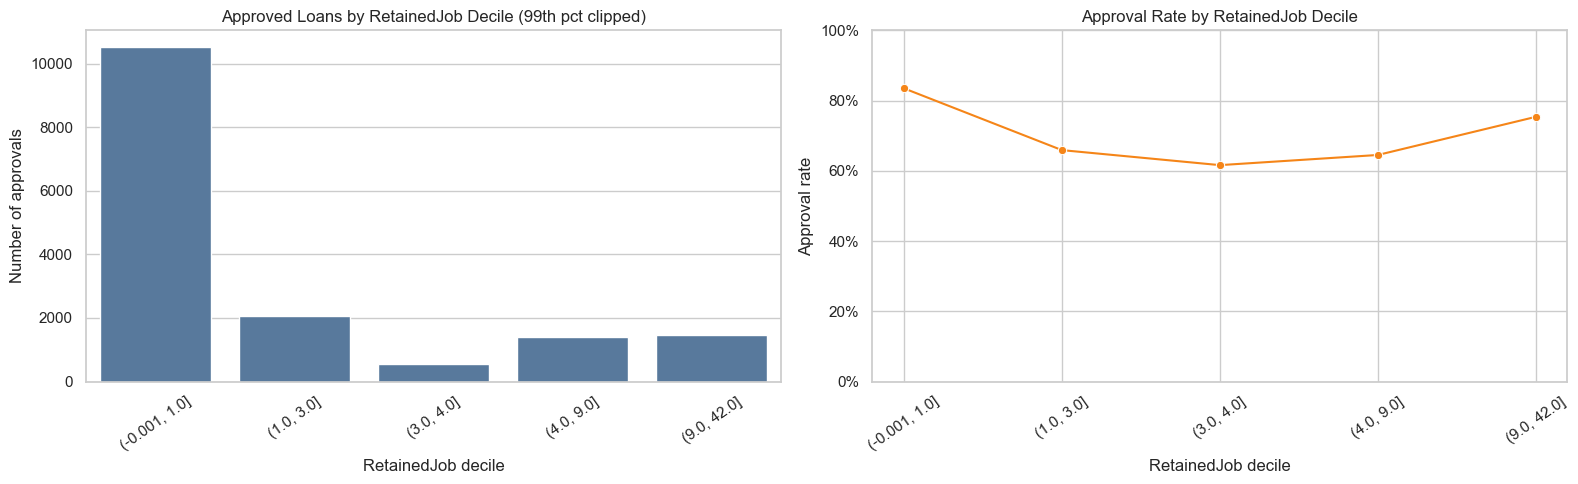

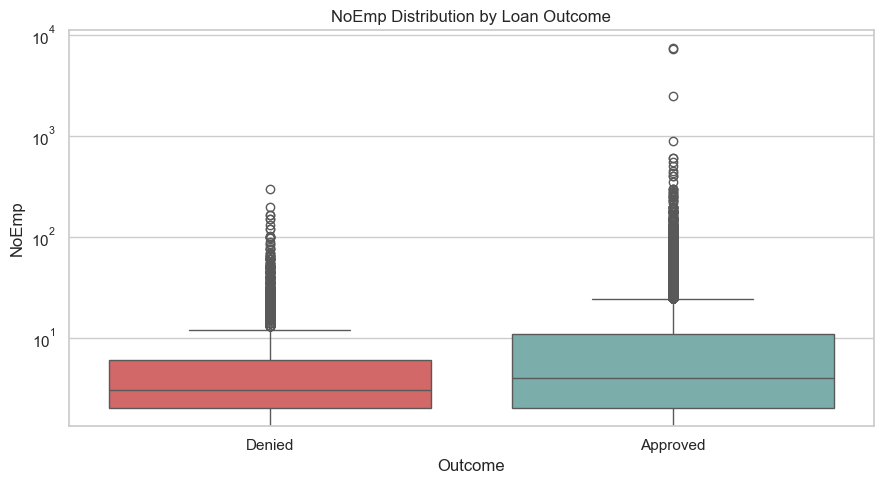

,RetainedJobBin,total,approvals,approval_rate
0,"(-0.001, 1.0]",12603,10524,0.835039
1,"(1.0, 3.0]",3153,2078,0.659055
2,"(3.0, 4.0]",920,567,0.616304
3,"(4.0, 9.0]",2162,1395,0.645236
4,"(9.0, 42.0]",1930,1455,0.753886


In [5]:
# RetainedJob vs NoEmp, and impact on Accept
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

analysis = df[["RetainedJob", "NoEmp", "Accept"]].copy()
analysis["RetainedJob"] = pd.to_numeric(analysis["RetainedJob"], errors="coerce")
analysis["NoEmp"] = pd.to_numeric(analysis["NoEmp"], errors="coerce")
analysis["Accept"] = pd.to_numeric(analysis["Accept"], errors="coerce")
analysis = analysis.dropna(subset=["RetainedJob", "NoEmp", "Accept"])

if analysis.empty:
    print("No valid rows found after cleaning RetainedJob/NoEmp/Accept.")
else:
    sns.set_theme(style="whitegrid")

    # Keep labels consistent and robust for plotting
    analysis["AcceptInt"] = analysis["Accept"].round().astype(int)
    analysis["AcceptLabel"] = analysis["AcceptInt"].map({0: "Denied", 1: "Approved"}).fillna("Other")

    # 1) Relationship between RetainedJob and NoEmp (log view to handle heavy skew/outliers)
    corr = analysis[["RetainedJob", "NoEmp"]].corr().loc["RetainedJob", "NoEmp"]
    plot_rel = analysis[(analysis["RetainedJob"] >= 0) & (analysis["NoEmp"] >= 0)].copy()
    plot_rel["RetainedJob_log1p"] = np.log1p(plot_rel["RetainedJob"])
    plot_rel["NoEmp_log1p"] = np.log1p(plot_rel["NoEmp"])

    plt.figure(figsize=(9, 5))
    sns.scatterplot(
        data=plot_rel.sample(min(len(plot_rel), 6000), random_state=42) if len(plot_rel) > 0 else plot_rel,
        x="RetainedJob_log1p",
        y="NoEmp_log1p",
        alpha=0.25,
        s=20
    )
    sns.regplot(
        data=plot_rel,
        x="RetainedJob_log1p",
        y="NoEmp_log1p",
        scatter=False,
        line_kws={"color": "#d62728", "lw": 2}
    )
    plt.title(f"RetainedJob vs NoEmp (log1p scale, Pearson r = {corr:.3f})")
    plt.xlabel("log(1 + RetainedJob)")
    plt.ylabel("log(1 + NoEmp)")
    plt.tight_layout()
    plt.show()

    # 2) Effect of RetainedJob on approvals: bin RetainedJob to show stable approval rates
    q = analysis["RetainedJob"].quantile(0.99)
    clipped = analysis.copy()
    clipped["RetainedJob_clipped"] = clipped["RetainedJob"].clip(upper=q)

    clipped["RetainedJobBin"] = pd.qcut(
        clipped["RetainedJob_clipped"],
        q=10,
        duplicates="drop"
    )

    agg_bin = (
        clipped.groupby("RetainedJobBin", observed=False)["AcceptInt"]
        .agg(total="count", approvals="sum")
        .reset_index()
    )
    agg_bin["approval_rate"] = agg_bin["approvals"] / agg_bin["total"]
    agg_bin["bin_label"] = agg_bin["RetainedJobBin"].astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(data=agg_bin, x="bin_label", y="approvals", color="#4c78a8", ax=axes[0])
    axes[0].set_title("Approved Loans by RetainedJob Decile (99th pct clipped)")
    axes[0].set_xlabel("RetainedJob decile")
    axes[0].set_ylabel("Number of approvals")
    axes[0].tick_params(axis="x", rotation=35)

    sns.lineplot(
        data=agg_bin,
        x="bin_label",
        y="approval_rate",
        marker="o",
        color="#f58518",
        ax=axes[1]
    )
    axes[1].set_title("Approval Rate by RetainedJob Decile")
    axes[1].set_xlabel("RetainedJob decile")
    axes[1].set_ylabel("Approval rate")
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis="x", rotation=35)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

    plt.tight_layout()
    plt.show()

    # 3) NoEmp distribution by approval outcome
    plt.figure(figsize=(9, 5))
    sns.boxplot(
        data=analysis[analysis["AcceptLabel"].isin(["Denied", "Approved"])],
        x="AcceptLabel",
        y="NoEmp",
        hue="AcceptLabel",
        legend=False,
        palette={"Denied": "#e45756", "Approved": "#72b7b2"}
    )
    plt.title("NoEmp Distribution by Loan Outcome")
    plt.xlabel("Outcome")
    plt.ylabel("NoEmp")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

    display(agg_bin[["RetainedJobBin", "total", "approvals", "approval_rate"]])

### Key Findings
- `RetainedJob` and `NoEmp` have very weak linear association in this run, so they should not be treated as interchangeable predictors.
- Approval behavior by retained-job bins is non-monotonic, which suggests interaction effects rather than a simple linear trend.
- Workforce size differences by outcome remain visible, reinforcing the broader company-scale pattern.

## 9) Consolidated Denial-Risk Audit
Aggregate the categorical and numeric risk slices into one compact view.

This helps prioritize features for the final modeling pipeline.

Rows used: 20,768
Overall Accept = 0 rate: 22.87%

BankState - highest Accept = 0 groups (min 100 rows)


,BankStateLabel,total,denied,denied_rate
3,CA,1324,700,0.528701
7,DE,663,344,0.518854
32,RI,1334,581,0.435532
39,VA,567,241,0.425044
21,NC,443,183,0.413093
26,NY,348,117,0.336207
34,SD,429,108,0.251748
27,OH,1105,275,0.248869
36,TX,249,59,0.236948
19,MO,124,25,0.201613


NewExist - highest Accept = 0 groups (min 50 rows)


,NewExistLabel,total,denied,denied_rate
0,Existing business,14178,3320,0.234166
1,New business,6577,1428,0.217120


FranchiseCode - highest Accept = 0 groups (min 50 rows)


...

,bucket,total,denied,denied_rate
2,"(1.386, 1.609]",920,353,0.383696
3,"(1.609, 2.303]",2162,767,0.354764
1,"(0.693, 1.386]",3153,1075,0.340945
4,"(2.303, 9.083]",1930,475,0.246114
0,"(-0.001, 0.693]",12603,2079,0.164961


DisbursementGross - highest Accept = 0 buckets


,bucket,total,denied,denied_rate
0,"(-0.001, 9.904]",2323,878,0.377960
1,"(9.904, 10.401]",1831,476,0.259967
3,"(10.82, 11.103]",1316,326,0.247720
4,"(11.103, 11.439]",2076,513,0.247110
5,"(11.439, 11.664]",2077,503,0.242176
2,"(10.401, 10.82]",2838,687,0.242072
6,"(11.664, 11.984]",2076,437,0.210501
7,"(11.984, 12.468]",2084,428,0.205374
8,"(12.468, 13.071]",2078,288,0.138595
9,"(13.071, 16.012]",2069,213,0.102948


BalanceGross: not enough variation for binning
Binary zero-flag combinations with highest Accept = 0 rate


,NoEmp_is_zero,CreateJob_is_zero,RetainedJob_is_zero,BalanceGross_is_zero,total,denied,denied_rate
0,0,0,0,1,5188,1832,0.353123
6,1,1,0,1,20,7,0.350000
2,0,1,0,1,5021,1579,0.314479
4,1,0,0,1,55,15,0.272727
7,1,1,1,1,70,15,0.214286
5,1,0,1,1,67,13,0.194030
3,0,1,1,1,8808,1184,0.134423
1,0,0,1,1,1539,104,0.067576


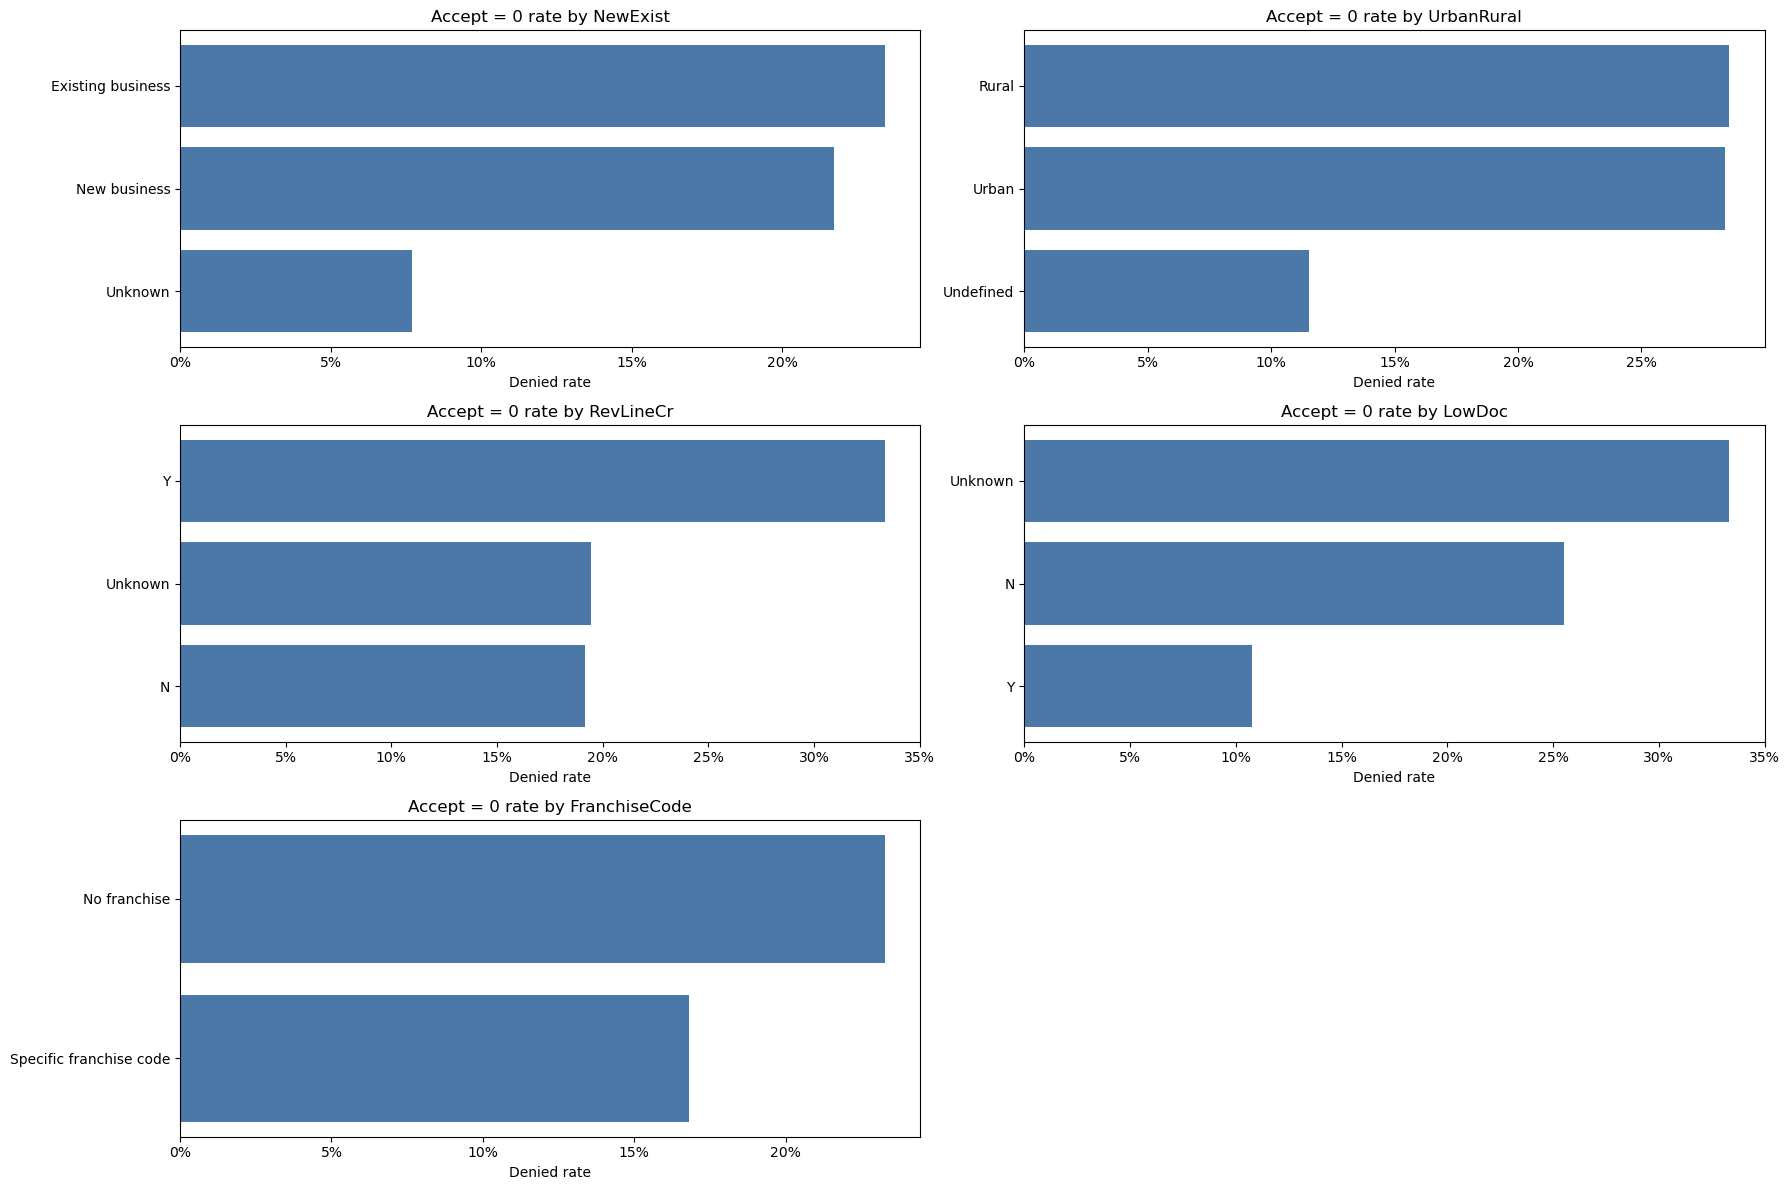

Top denial-prone options across the requested columns


,Feature,BankStateLabel,total,denied,denied_rate,NewExistLabel,FranchiseLabel,UrbanRuralLabel,RevLineCrLabel,LowDocLabel,bucket
0,BankState,CA,1324,700,0.528701,NaN,NaN,NaN,<NA>,<NA>,NaN
1,BankState,DE,663,344,0.518854,NaN,NaN,NaN,<NA>,<NA>,NaN
2,BankState,RI,1334,581,0.435532,NaN,NaN,NaN,<NA>,<NA>,NaN
3,BankState,VA,567,241,0.425044,NaN,NaN,NaN,<NA>,<NA>,NaN
4,BankState,NC,443,183,0.413093,NaN,NaN,NaN,<NA>,<NA>,NaN
27,RetainedJob,<NA>,920,353,0.383696,NaN,NaN,NaN,<NA>,<NA>,"(1.386, 1.609]"
32,DisbursementGross,<NA>,2323,878,0.377960,NaN,NaN,NaN,<NA>,<NA>,"(-0.001, 9.904]"
23,CreateJob,<NA>,1475,528,0.357966,NaN,NaN,NaN,<NA>,<NA>,"(0.693, 1.099]"
28,RetainedJob,<NA>,2162,767,0.354764,NaN,NaN,NaN,<NA>,<NA>,"(1.609, 2.303]"
29,RetainedJob,<NA>,3153,1075,0.340945,NaN,NaN,NaN,<NA>,<NA>,"(0.693, 1.386]"


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

# Keep this cell self-contained and limited to the requested columns.
required_cols = [
    "BankState",
    "NoEmp",
    "NewExist",
    "CreateJob",
    "RetainedJob",
    "FranchiseCode",
    "UrbanRural",
    "RevLineCr",
    "LowDoc",
    "DisbursementGross",
    "BalanceGross",
    "Accept",
]


def resolve_train_path() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "data" / "train.csv"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not locate data/train.csv from the current notebook working directory.")


if "df" not in globals() or not isinstance(df, pd.DataFrame):
    df = pd.read_csv(resolve_train_path())

analysis = df[required_cols].copy()

# Normalize the target and keep only valid labels.
analysis["Accept"] = pd.to_numeric(analysis["Accept"], errors="coerce")
analysis = analysis[analysis["Accept"].isin([0, 1])].copy()
analysis["AcceptInt"] = analysis["Accept"].astype(int)
analysis["Denied"] = (analysis["AcceptInt"] == 0).astype(int)

# Clean the columns described in about-data.md.
for col in ["BankState", "RevLineCr", "LowDoc"]:
    analysis[col] = analysis[col].astype("string").str.strip().str.upper()

for col in ["NoEmp", "NewExist", "CreateJob", "RetainedJob", "FranchiseCode", "UrbanRural", "DisbursementGross", "BalanceGross"]:
    analysis[col] = (
        analysis[col]
        .astype("string")
        .str.replace(r"[^0-9\.-]", "", regex=True)
        .replace("", np.nan)
    )
    analysis[col] = pd.to_numeric(analysis[col], errors="coerce")

analysis["NewExistLabel"] = analysis["NewExist"].map({1: "Existing business", 2: "New business"}).fillna("Unknown")
analysis["UrbanRuralLabel"] = analysis["UrbanRural"].map({0: "Undefined", 1: "Urban", 2: "Rural"}).fillna("Unknown")
analysis["RevLineCrLabel"] = analysis["RevLineCr"].where(analysis["RevLineCr"].isin(["Y", "N"]), "Unknown")
analysis["LowDocLabel"] = analysis["LowDoc"].where(analysis["LowDoc"].isin(["Y", "N"]), "Unknown")
analysis["FranchiseLabel"] = np.where(analysis["FranchiseCode"].isin([0, 1]), "No franchise", "Specific franchise code")
analysis.loc[analysis["FranchiseCode"].isna(), "FranchiseLabel"] = "Unknown"
analysis["BankStateLabel"] = analysis["BankState"].fillna("Unknown")

overall = analysis["Denied"].mean()
print(f"Rows used: {len(analysis):,}")
print(f"Overall Accept = 0 rate: {overall:.2%}")
print()

# Categorical risk audit: show the most denial-prone options for each column.
def top_denial_groups(frame, feature, label=None, min_count=50, top_n=8):
    label = label or feature
    summary = (
        frame.groupby(feature, dropna=False)
        .agg(
            total=("Denied", "size"),
            denied=("Denied", "sum"),
            denied_rate=("Denied", "mean"),
        )
        .reset_index()
        .sort_values(["denied_rate", "total"], ascending=[False, False])
    )
    summary = summary[summary["total"] >= min_count].head(top_n)
    if summary.empty:
        print(f"{label}: no groups with at least {min_count} rows")
        return summary
    print(f"{label} - highest Accept = 0 groups (min {min_count} rows)")
    display(summary)
    return summary

cat_tables = [
    top_denial_groups(analysis, "BankStateLabel", "BankState", min_count=100, top_n=10),
    top_denial_groups(analysis, "NewExistLabel", "NewExist", min_count=50, top_n=10),
    top_denial_groups(analysis, "FranchiseLabel", "FranchiseCode", min_count=50, top_n=10),
    top_denial_groups(analysis, "UrbanRuralLabel", "UrbanRural", min_count=50, top_n=10),
    top_denial_groups(analysis, "RevLineCrLabel", "RevLineCr", min_count=50, top_n=10),
    top_denial_groups(analysis, "LowDocLabel", "LowDoc", min_count=50, top_n=10),
]

# Numeric risk audit: bin continuous values and measure denial rate by bucket.
def binned_denial_audit(frame, feature, bins=10, min_count=50, log1p=False):
    series = frame[feature].copy()
    if log1p:
        series = np.log1p(series.clip(lower=0))
    valid = frame.loc[series.notna(), ["Denied"]].copy()
    valid["bucket_source"] = series.loc[series.notna()]
    if valid["bucket_source"].nunique() < 3:
        print(f"{feature}: not enough variation for binning")
        return pd.DataFrame()
    try:
        valid["bucket"] = pd.qcut(valid["bucket_source"], q=bins, duplicates="drop")
    except ValueError:
        valid["bucket"] = pd.cut(valid["bucket_source"], bins=min(bins, valid["bucket_source"].nunique()))
    summary = (
        valid.groupby("bucket", observed=False)
        .agg(total=("Denied", "size"), denied=("Denied", "sum"), denied_rate=("Denied", "mean"))
        .reset_index()
        .sort_values(["denied_rate", "total"], ascending=[False, False])
    )
    summary = summary[summary["total"] >= min_count]
    print(f"{feature} - highest Accept = 0 buckets")
    display(summary.head(10))
    return summary

num_tables = [
    binned_denial_audit(analysis, "NoEmp", bins=10, min_count=100, log1p=True),
    binned_denial_audit(analysis, "CreateJob", bins=10, min_count=100, log1p=True),
    binned_denial_audit(analysis, "RetainedJob", bins=10, min_count=100, log1p=True),
    binned_denial_audit(analysis, "DisbursementGross", bins=10, min_count=100, log1p=True),
    binned_denial_audit(analysis, "BalanceGross", bins=10, min_count=25, log1p=True),
]

# Quick flags that are often informative for denial behavior.
analysis["NoEmp_is_zero"] = (analysis["NoEmp"] == 0).astype(int)
analysis["CreateJob_is_zero"] = (analysis["CreateJob"] == 0).astype(int)
analysis["RetainedJob_is_zero"] = (analysis["RetainedJob"] == 0).astype(int)
analysis["BalanceGross_is_zero"] = (analysis["BalanceGross"] == 0).astype(int)

flag_summary = (
    analysis.groupby(["NoEmp_is_zero", "CreateJob_is_zero", "RetainedJob_is_zero", "BalanceGross_is_zero"], dropna=False)
    .agg(total=("Denied", "size"), denied=("Denied", "sum"), denied_rate=("Denied", "mean"))
    .reset_index()
    .sort_values(["denied_rate", "total"], ascending=[False, False])
)
print("Binary zero-flag combinations with highest Accept = 0 rate")
display(flag_summary.head(10))

# Compact visual summary for the strongest categorical signals.
plot_frames = []
for feature, column in [
    ("NewExist", "NewExistLabel"),
    ("UrbanRural", "UrbanRuralLabel"),
    ("RevLineCr", "RevLineCrLabel"),
    ("LowDoc", "LowDocLabel"),
    ("FranchiseCode", "FranchiseLabel"),
]:
    temp = (
        analysis.groupby(column, dropna=False)["Denied"]
        .mean()
        .rename("DeniedRate")
        .reset_index()
        .rename(columns={column: "Option"})
    )
    temp["Feature"] = feature
    plot_frames.append(temp)

plot_source = pd.concat(plot_frames, ignore_index=True)
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
axes = axes.flatten()
for ax, feature in zip(axes, ["NewExist", "UrbanRural", "RevLineCr", "LowDoc", "FranchiseCode"]):
    subset = plot_source[plot_source["Feature"] == feature].sort_values("DeniedRate", ascending=False)
    ax.barh(subset["Option"].astype(str), subset["DeniedRate"], color="#4c78a8")
    ax.invert_yaxis()
    ax.set_title(f"Accept = 0 rate by {feature}")
    ax.set_xlabel("Denied rate")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

axes[-1].axis("off")
plt.tight_layout()
plt.show()

# Final compact takeaway table: highest denial-rate buckets across all audited groups.
all_tables = []
for feature, table in [
    ("BankState", cat_tables[0]),
    ("NewExist", cat_tables[1]),
    ("FranchiseCode", cat_tables[2]),
    ("UrbanRural", cat_tables[3]),
    ("RevLineCr", cat_tables[4]),
    ("LowDoc", cat_tables[5]),
    ("NoEmp", num_tables[0]),
    ("CreateJob", num_tables[1]),
    ("RetainedJob", num_tables[2]),
    ("DisbursementGross", num_tables[3]),
    ("BalanceGross", num_tables[4]),
]:
    if table is not None and len(table) > 0:
        temp = table.head(5).copy()
        temp.insert(0, "Feature", feature)
        all_tables.append(temp)

if all_tables:
    takeaway = pd.concat(all_tables, ignore_index=True)
    print("Top denial-prone options across the requested columns")
    display(takeaway.sort_values(["denied_rate", "total"], ascending=[False, False]).head(20))
else:
    print("No stable groups found for the requested denial audit.")

### Job Signal Overview
Check how the engineered job features behave after preprocessing and whether they separate approvals from denials.

- Compare `jobs_total`, `jobs_gap`, and `jobs_total_log` across `Accept`.
- Use histograms to inspect overlap, skew, and rough separation.
- Use boxplots to highlight spread and outliers by class.

jobs columns present: ['jobs_total', 'jobs_gap', 'jobs_total_log']
Rows used for analysis: 20768

Summary by Accept:
       jobs_total                                               jobs_gap  \
            count    mean      std  min  25%  50%  75%      max    count   
Accept                                                                     
0          4749.0  35.255  721.696  0.0  0.0  3.0  6.0  17600.0   4749.0   
1         16019.0   8.948  241.349  0.0  0.0  1.0  6.0  17600.0  16019.0   

               ...             jobs_total_log                                 \
         mean  ...  75%    max          count   mean    std  min  25%    50%   
Accept         ...                                                             
0       2.403  ...  3.0  200.0         4749.0  1.343  1.072  0.0  0.0  1.386   
1       0.853  ...  2.0  350.0        16019.0  1.029  1.183  0.0  0.0  0.693   

                      
          75%    max  
Accept                
0       1.946  9.776  
1       1

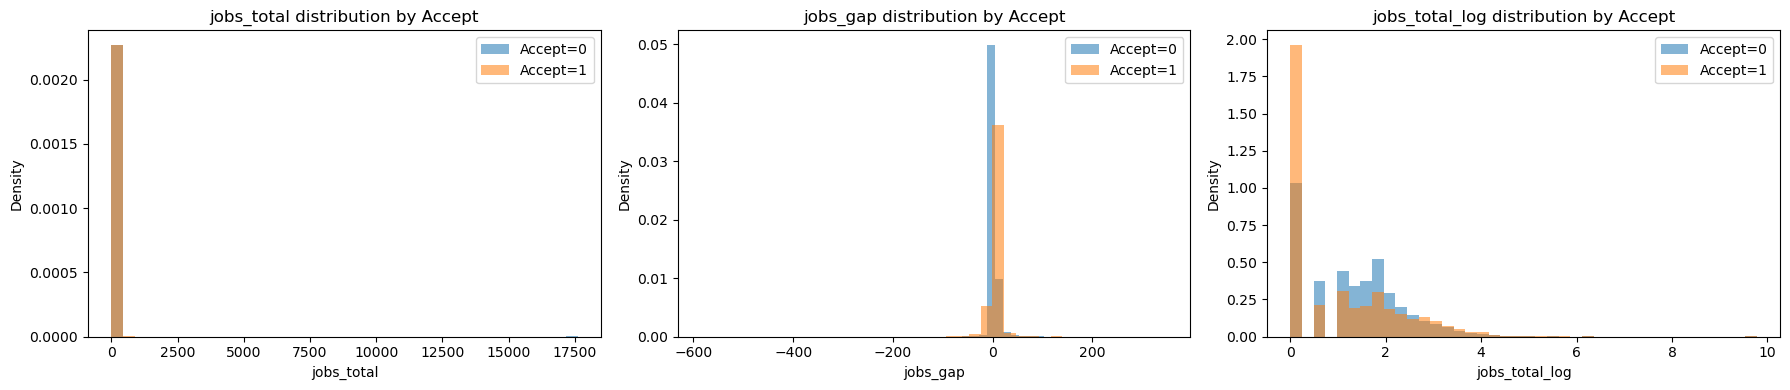

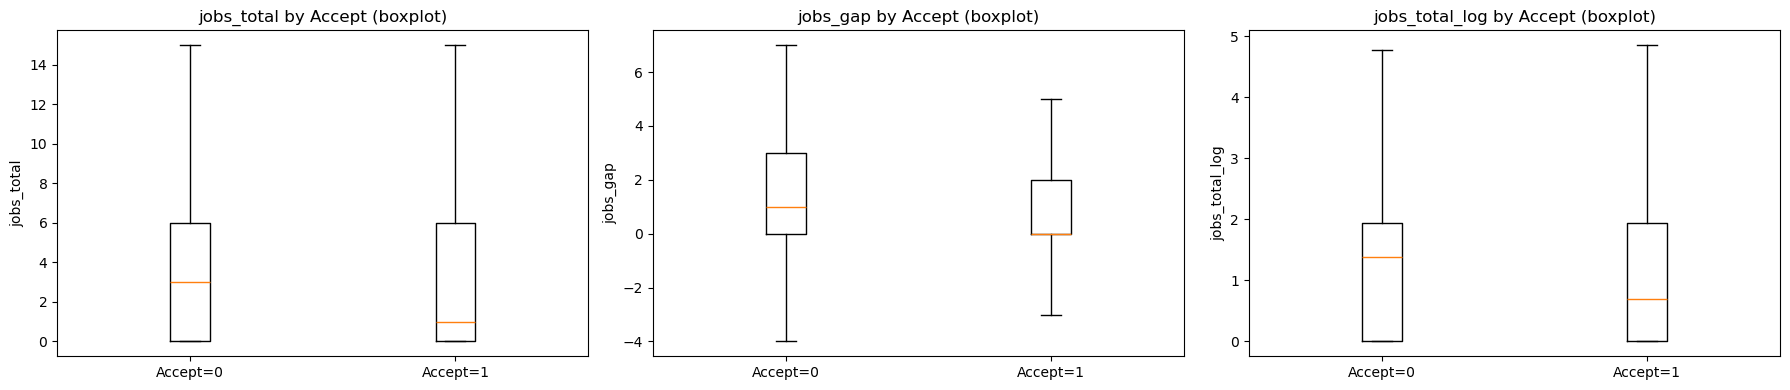

In [ ]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure src/ is importable when notebook runs from notebooks/team-notebooks
project_root = Path.cwd().resolve().parents[1]
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Force reload so notebook sees latest edits in src/preprocessing/one_step.py
import preprocessing.one_step as one_step
importlib.reload(one_step)
OneStepOptions = one_step.OneStepOptions
preprocess_one_step = one_step.preprocess_one_step

# Load training data
df_raw = pd.read_csv(project_root / 'data' / 'train.csv')

# Use tree-focused preprocessing so engineered jobs_* columns are created
opts = OneStepOptions(
    noemp_option='trees',
    newexist_option='A',
    createjob_option='trees',
    retainedjob_option='trees',
    approvaldate_option='C',
    approvalfy_option='B',
    franchise_option='binary',
    urbanrural_option='onehot',
    revlinecr_option='C',
    lowdoc_option='C',
    disbursementgross_option='trees',
    balancegross_option='trees',
    local_state='IL',
)

df_proc = preprocess_one_step(df_raw, options=opts, is_tree_model=True)
print('jobs columns present:', [c for c in ['jobs_total', 'jobs_gap', 'jobs_total_log'] if c in df_proc.columns])

# Safety net: if jobs_total_log is still missing, create it on-the-fly for analysis
if 'jobs_total_log' not in df_proc.columns and 'jobs_total' in df_proc.columns:
    df_proc['jobs_total_log'] = np.log1p(pd.to_numeric(df_proc['jobs_total'], errors='coerce').clip(lower=0))
    print("[INFO] Built jobs_total_log from jobs_total inside notebook cell.")

analysis_cols = ['jobs_total', 'jobs_gap', 'jobs_total_log', 'Accept']
missing = [c for c in analysis_cols if c not in df_proc.columns]
if missing:
    raise ValueError(f'Missing expected columns after reload/fallback: {missing}')

df_plot = df_proc[analysis_cols].copy().dropna()
df_plot['Accept'] = df_plot['Accept'].astype(int)

print('Rows used for analysis:', len(df_plot))
print('\nSummary by Accept:')
print(df_plot.groupby('Accept')[['jobs_total', 'jobs_gap', 'jobs_total_log']].describe().round(3))

# Correlation with binary target as a quick signal-strength view
corr = df_plot[['jobs_total', 'jobs_gap', 'jobs_total_log', 'Accept']].corr(numeric_only=True)['Accept'].drop('Accept')
print('\nPearson correlation with Accept:')
print(corr.sort_values(ascending=False).round(4))

# Plot 1: class-wise distributions
features = ['jobs_total', 'jobs_gap', 'jobs_total_log']
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(features):
    a0 = df_plot.loc[df_plot['Accept'] == 0, col]
    a1 = df_plot.loc[df_plot['Accept'] == 1, col]
    axes[i].hist(a0, bins=40, alpha=0.55, label='Accept=0', density=True)
    axes[i].hist(a1, bins=40, alpha=0.55, label='Accept=1', density=True)
    axes[i].set_title(f'{col} distribution by Accept')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()
plt.tight_layout()
plt.show()

# Plot 2: boxplots for separation/outlier view
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(features):
    data_0 = df_plot.loc[df_plot['Accept'] == 0, col].values
    data_1 = df_plot.loc[df_plot['Accept'] == 1, col].values
    axes[i].boxplot([data_0, data_1], tick_labels=['Accept=0', 'Accept=1'], showfliers=False)
    axes[i].set_title(f'{col} by Accept (boxplot)')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

### Raw Job Feature Check
Look at the source `CreateJob` and `RetainedJob` values before treating them as model signals.

- Compare missing, zero, and positive values for both job features.
- Use histograms to inspect skew, spread, and class overlap.
- Use boxplots to highlight separation and outliers by `Accept`.

Data quality summary (raw input columns):
                rows  missing_n  missing_pct   zero_n  zero_pct_of_valid  \
CreateJob    20768.0        0.0          0.0  13919.0              67.02   
RetainedJob  20768.0        0.0          0.0  10484.0              50.48   

             positive_n  positive_pct_of_valid  
CreateJob        6849.0                  32.98  
RetainedJob     10284.0                  49.52  


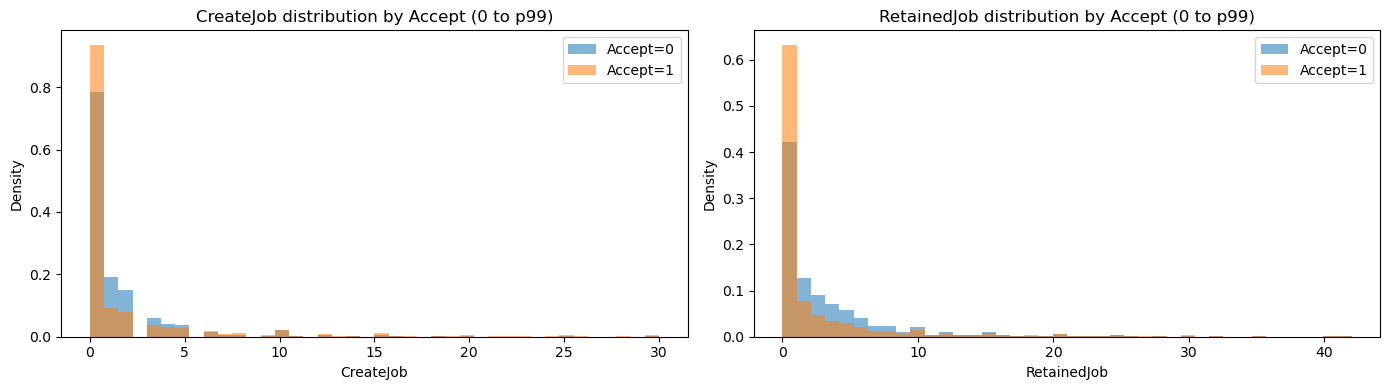

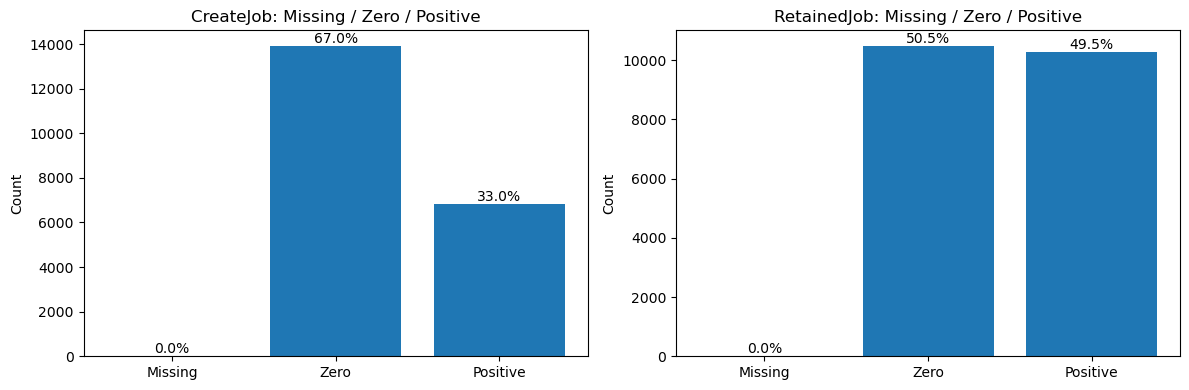

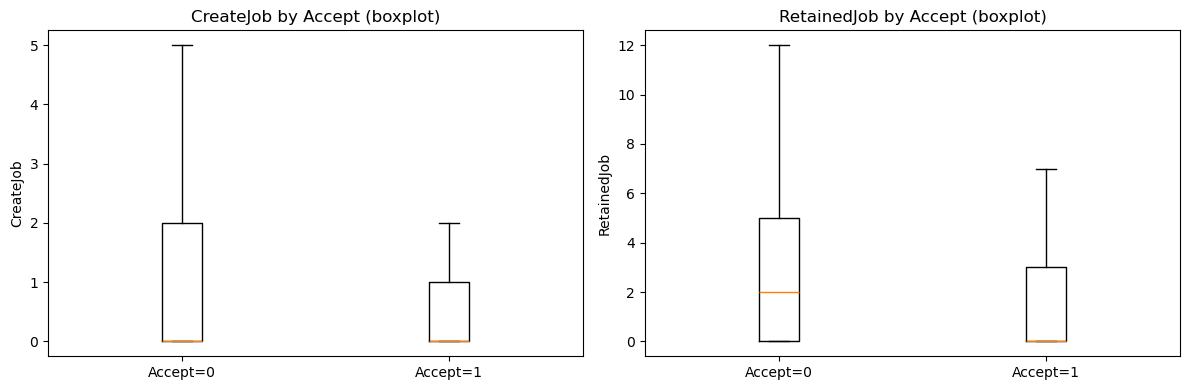

In [ ]:
# Cell 2: Data quality and distribution analysis for CreateJob and RetainedJob
jobs_cols = ['CreateJob', 'RetainedJob', 'Accept']
missing_cols = [c for c in jobs_cols if c not in df_raw.columns]
if missing_cols:
    raise ValueError(f'Missing expected raw columns: {missing_cols}')

df_jobs_raw = df_raw[jobs_cols].copy()
df_jobs_raw['CreateJob'] = pd.to_numeric(df_jobs_raw['CreateJob'], errors='coerce')
df_jobs_raw['RetainedJob'] = pd.to_numeric(df_jobs_raw['RetainedJob'], errors='coerce')
df_jobs_raw['Accept'] = pd.to_numeric(df_jobs_raw['Accept'], errors='coerce').astype('Int64')

def quality_table(series: pd.Series) -> dict:
    valid = series.dropna()
    return {
        'rows': len(series),
        'missing_n': int(series.isna().sum()),
        'missing_pct': float(series.isna().mean() * 100),
        'zero_n': int((valid == 0).sum()),
        'zero_pct_of_valid': float(((valid == 0).mean() * 100) if len(valid) else np.nan),
        'positive_n': int((valid > 0).sum()),
        'positive_pct_of_valid': float(((valid > 0).mean() * 100) if len(valid) else np.nan),
    }

quality = pd.DataFrame({
    'CreateJob': quality_table(df_jobs_raw['CreateJob']),
    'RetainedJob': quality_table(df_jobs_raw['RetainedJob']),
}).T.round(2)

print('Data quality summary (raw input columns):')
print(quality)

# Distribution plots with robust x-limits (trim extreme outliers for readability)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, col in enumerate(['CreateJob', 'RetainedJob']):
    s = df_jobs_raw[col].dropna()
    x_max = float(np.nanpercentile(s, 99)) if len(s) else 1.0
    a0 = df_jobs_raw.loc[df_jobs_raw['Accept'] == 0, col].dropna()
    a1 = df_jobs_raw.loc[df_jobs_raw['Accept'] == 1, col].dropna()
    axes[i].hist(a0, bins=40, alpha=0.55, label='Accept=0', density=True, range=(0, x_max))
    axes[i].hist(a1, bins=40, alpha=0.55, label='Accept=1', density=True, range=(0, x_max))
    axes[i].set_title(f'{col} distribution by Accept (0 to p99)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()
plt.tight_layout()
plt.show()

# Category mix to test the 'not requested' hypothesis: Missing vs Zero vs Positive
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(['CreateJob', 'RetainedJob']):
    s = df_jobs_raw[col]
    cats = pd.Series(np.where(s.isna(), 'Missing', np.where(s == 0, 'Zero', 'Positive')))
    counts = cats.value_counts().reindex(['Missing', 'Zero', 'Positive']).fillna(0)
    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(f'{col}: Missing / Zero / Positive')
    axes[i].set_ylabel('Count')
    for x, y in enumerate(counts.values):
        pct = 100.0 * y / len(s)
        axes[i].text(x, y, f'{pct:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Boxplots by target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(['CreateJob', 'RetainedJob']):
    d0 = df_jobs_raw.loc[df_jobs_raw['Accept'] == 0, col].dropna()
    d1 = df_jobs_raw.loc[df_jobs_raw['Accept'] == 1, col].dropna()
    axes[i].boxplot([d0, d1], tick_labels=['Accept=0', 'Accept=1'], showfliers=False)
    axes[i].set_title(f'{col} by Accept (boxplot)')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

### Raw Job Feature Quality
Inspect the source `CreateJob` and `RetainedJob` fields before treating them as model signals (for tree models). These fields are sparse and skewed, so the difference between zero and positive values may matter more than raw magnitude.


CreateJob - Accept rate by zero vs positive:
   group  n_rows  accept_rate
    zero   13919     0.799914
positive    6849     0.713243
Absolute lift (positive - zero): -8.67 pp
Relative lift: -10.84%

RetainedJob - Accept rate by zero vs positive:
   group  n_rows  accept_rate
    zero   10484     0.874475
positive   10284     0.666180
Absolute lift (positive - zero): -20.83 pp
Relative lift: -23.82%


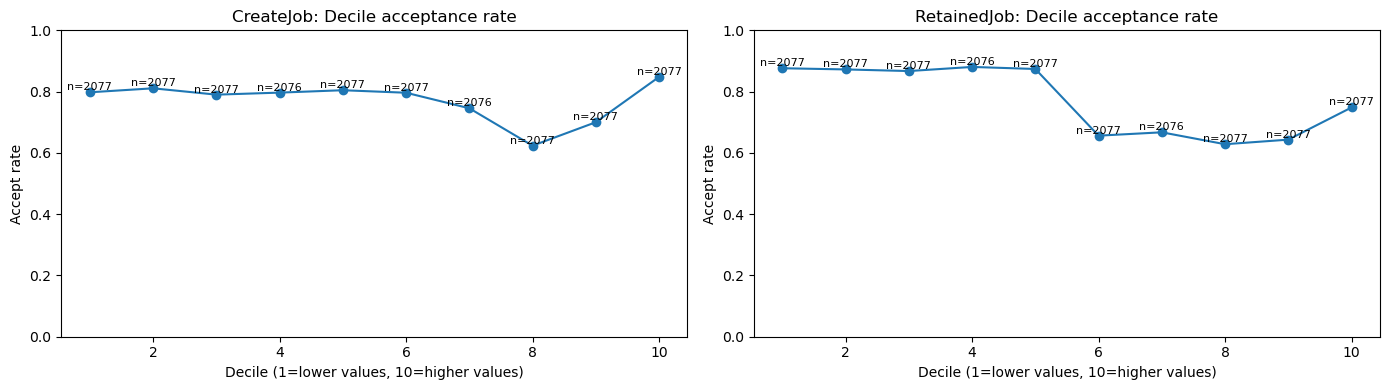

In [ ]:
# Cell 3: Quantify predictive lift for CreateJob/RetainedJob
df_lift = df_jobs_raw[['CreateJob', 'RetainedJob', 'Accept']].copy().dropna()
df_lift['Accept'] = df_lift['Accept'].astype(int)

def acceptance_rate(series, target):
    tmp = pd.DataFrame({'x': series, 'y': target}).dropna()
    return float(tmp['y'].mean()) if len(tmp) else np.nan

def zero_vs_positive_lift(df_in: pd.DataFrame, feature: str) -> pd.DataFrame:
    s = pd.to_numeric(df_in[feature], errors='coerce')
    y = pd.to_numeric(df_in['Accept'], errors='coerce')
    mask_zero = s == 0
    mask_pos = s > 0

    rate_zero = acceptance_rate(s[mask_zero], y[mask_zero])
    rate_pos = acceptance_rate(s[mask_pos], y[mask_pos])
    abs_lift_pp = (rate_pos - rate_zero) * 100.0
    rel_lift_pct = ((rate_pos / rate_zero) - 1.0) * 100.0 if rate_zero > 0 else np.nan

    return pd.DataFrame({
        'group': ['zero', 'positive'],
        'n_rows': [int(mask_zero.sum()), int(mask_pos.sum())],
        'accept_rate': [rate_zero, rate_pos],
    }), abs_lift_pp, rel_lift_pct

for feat in ['CreateJob', 'RetainedJob']:
    summary_df, abs_lift_pp, rel_lift_pct = zero_vs_positive_lift(df_lift, feat)
    print(f'\n{feat} - Accept rate by zero vs positive:')
    print(summary_df.to_string(index=False))
    print(f'Absolute lift (positive - zero): {abs_lift_pp:.2f} pp')
    print(f'Relative lift: {rel_lift_pct:.2f}%')

# Decile-binned acceptance-rate curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, feat in enumerate(['CreateJob', 'RetainedJob']):
    x = pd.to_numeric(df_lift[feat], errors='coerce')
    y = pd.to_numeric(df_lift['Accept'], errors='coerce')

    # qcut can fail on heavy ties; rank() creates a stable monotonic order for bins
    valid = pd.DataFrame({'x': x, 'y': y}).dropna().copy()
    valid['ranked'] = valid['x'].rank(method='first')
    valid['bin'] = pd.qcut(valid['ranked'], q=10, labels=False) + 1

    curve = valid.groupby('bin').agg(
        mean_feature=('x', 'mean'),
        accept_rate=('y', 'mean'),
        n=('y', 'size')
    ).reset_index()

    axes[i].plot(curve['bin'], curve['accept_rate'], marker='o')
    axes[i].set_title(f'{feat}: Decile acceptance rate')
    axes[i].set_xlabel('Decile (1=lower values, 10=higher values)')
    axes[i].set_ylabel('Accept rate')
    axes[i].set_ylim(0, 1)
    for _, row in curve.iterrows():
        axes[i].text(row['bin'], row['accept_rate'], f"n={int(row['n'])}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Franchise Stratification
Split the job signals by franchise status to test whether the lift persists after controlling for ownership structure.

Zero vs positive acceptance within franchise strata:
      segment     feature  n_total  n_zero  n_positive  accept_rate_zero  accept_rate_positive  lift_positive_minus_zero_pp
Non-franchise   CreateJob    19413   12955        6458            0.7963                0.7086                      -8.7716
    Franchise   CreateJob     1355     964         391            0.8485                0.7903                      -5.8266
Non-franchise RetainedJob    19413    9503        9910            0.8758                0.6629                     -21.2963
    Franchise RetainedJob     1355     981         374            0.8614                0.7540                     -10.7355


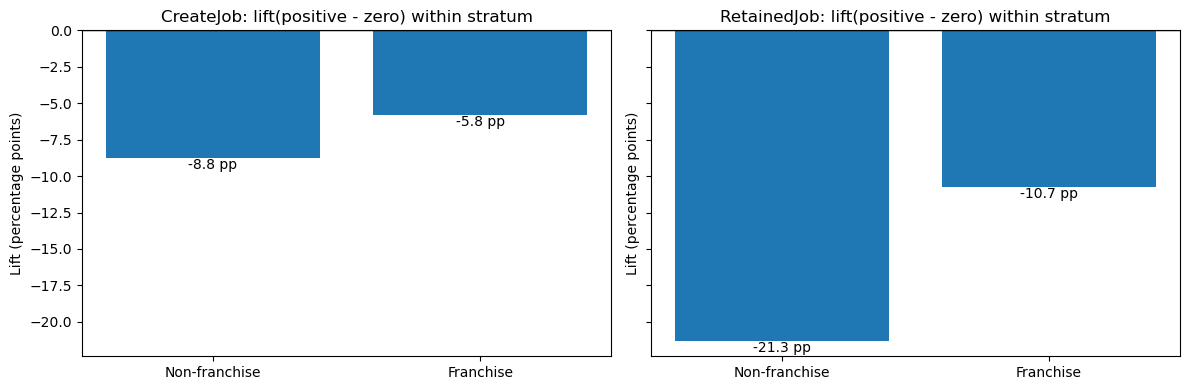


Baseline acceptance by franchise segment:
      segment  accept_rate     n
Non-franchise       0.7671 19413
    Franchise       0.8317  1355


In [ ]:
# Cell 5: Does franchise status absorb CreateJob/RetainedJob signal?
cols_needed = ['CreateJob', 'RetainedJob', 'Accept']
franchise_col = 'IsFranchise' if 'IsFranchise' in df_proc.columns else None
if franchise_col is None:
    raise ValueError("'IsFranchise' not found in df_proc. Check franchise preprocessing option.")

df_hyp = df_proc.copy()
for c in cols_needed:
    df_hyp[c] = pd.to_numeric(df_hyp[c], errors='coerce')
df_hyp[franchise_col] = pd.to_numeric(df_hyp[franchise_col], errors='coerce').fillna(0).astype(int)
df_hyp = df_hyp[cols_needed + [franchise_col]].dropna()
df_hyp['Accept'] = df_hyp['Accept'].astype(int)

def zero_pos_summary(df_in: pd.DataFrame, feature: str, group_col: str) -> pd.DataFrame:
    out = []
    for grp_val, grp_name in [(0, 'Non-franchise'), (1, 'Franchise')]:
        d = df_in[df_in[group_col] == grp_val].copy()
        if len(d) == 0:
            continue

        m0 = d[feature] == 0
        mp = d[feature] > 0
        rate0 = d.loc[m0, 'Accept'].mean() if m0.any() else np.nan
        ratep = d.loc[mp, 'Accept'].mean() if mp.any() else np.nan

        out.append({
            'segment': grp_name,
            'feature': feature,
            'n_total': int(len(d)),
            'n_zero': int(m0.sum()),
            'n_positive': int(mp.sum()),
            'accept_rate_zero': float(rate0) if pd.notna(rate0) else np.nan,
            'accept_rate_positive': float(ratep) if pd.notna(ratep) else np.nan,
            'lift_positive_minus_zero_pp': float((ratep - rate0) * 100.0) if pd.notna(rate0) and pd.notna(ratep) else np.nan,
        })
    return pd.DataFrame(out)

summary_create = zero_pos_summary(df_hyp, 'CreateJob', franchise_col)
summary_ret = zero_pos_summary(df_hyp, 'RetainedJob', franchise_col)
summary_all = pd.concat([summary_create, summary_ret], ignore_index=True)

print('Zero vs positive acceptance within franchise strata:')
print(summary_all.round(4).to_string(index=False))

# Plot the within-strata lift for quick visual check
plot_df = summary_all.copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i, feat in enumerate(['CreateJob', 'RetainedJob']):
    d = plot_df[plot_df['feature'] == feat]
    axes[i].bar(d['segment'], d['lift_positive_minus_zero_pp'])
    axes[i].axhline(0, color='black', linewidth=1)
    axes[i].set_title(f'{feat}: lift(positive - zero) within stratum')
    axes[i].set_ylabel('Lift (percentage points)')
    for x, y in enumerate(d['lift_positive_minus_zero_pp'].values):
        axes[i].text(x, y, f'{y:.1f} pp', ha='center', va='bottom' if y >= 0 else 'top')
plt.tight_layout()
plt.show()

# Extra check: Accept rate by franchise only (baseline effect)
base = df_hyp.groupby(franchise_col)['Accept'].agg(['mean', 'size']).reset_index()
base['segment'] = base[franchise_col].map({0: 'Non-franchise', 1: 'Franchise'}).fillna('Unknown')
print('\nBaseline acceptance by franchise segment:')
print(base[['segment', 'mean', 'size']].rename(columns={'mean': 'accept_rate', 'size': 'n'}).round(4).to_string(index=False))

### Compare With `NoEmp`, `CreateJob`, `RetainedJob`, `Accept`
Check whether the job counts agree with reported employee counts and whether acceptance changes with the retained-to-employee ratio.

Rows used: 20768

Basic summary:
           NoEmp  CreateJob  RetainedJob  retained_to_emp_ratio  \
count  20768.000  20768.000    20768.000              20556.000   
mean      10.784      6.878        8.085                  2.175   
std       76.659    202.723      202.633                 96.670   
min        0.000      0.000        0.000                  0.000   
25%        2.000      0.000        0.000                  0.000   
50%        4.000      0.000        0.000                  0.000   
75%       10.000      1.000        3.000                  1.000   
max     7389.000   8800.000     8800.000               8800.000   

       retained_minus_emp  
count           20768.000  
mean               -2.699  
std               216.331  
min             -7389.000  
25%                -6.000  
50%                -1.000  
75%                 0.000  
max              8799.000  

Share where RetainedJob > NoEmp: 8.37%

NoEmp vs RetainedJob bucket count matrix:
Retained_bucket     0   1-2 

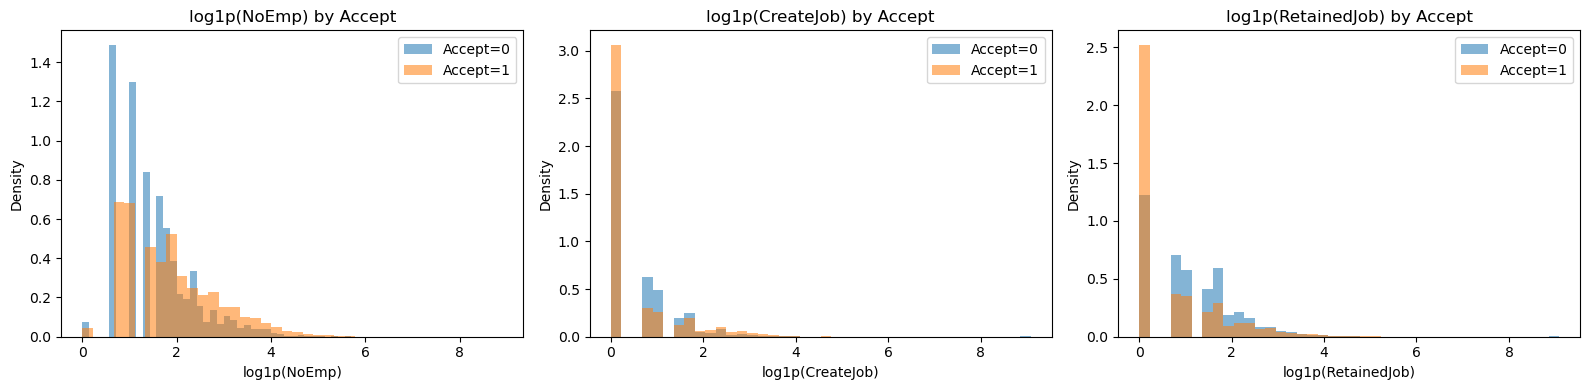

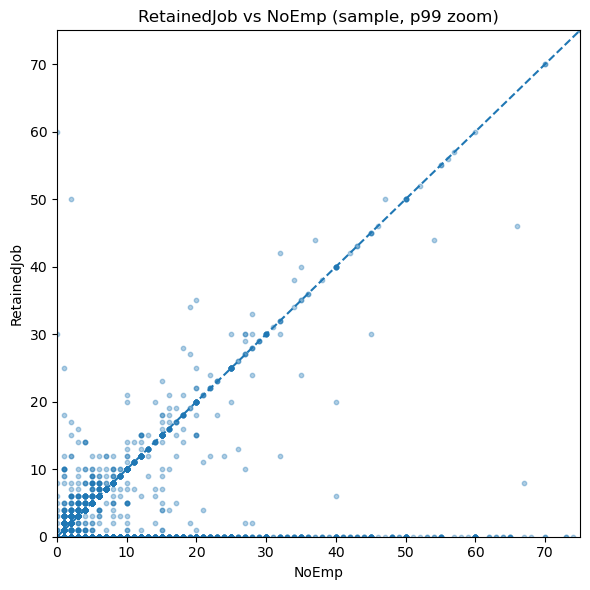


Acceptance by RetainedJob/NoEmp ratio bucket:
              accept_rate      n
ratio_bucket                    
0                  0.8755  10347
(0,0.5]            0.7909    330
(0.5,1.0]          0.6764   8215
(1.0,2.0]          0.5780   1225
>2.0               0.6196    439


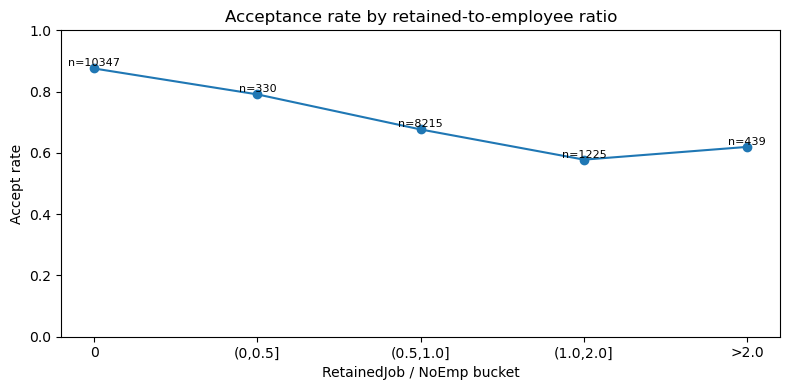

In [ ]:
# Cell 6: CreateJob/RetainedJob vs NoEmp (employee count)
emp_cols = ['NoEmp', 'CreateJob', 'RetainedJob', 'Accept']
emp_missing = [c for c in emp_cols if c not in df_raw.columns]
if emp_missing:
    raise ValueError(f'Missing expected columns in df_raw: {emp_missing}')

df_emp = df_raw[emp_cols].copy()
for c in ['NoEmp', 'CreateJob', 'RetainedJob', 'Accept']:
    df_emp[c] = pd.to_numeric(df_emp[c], errors='coerce')

# Keep a clean analysis frame
df_emp = df_emp.dropna(subset=['NoEmp', 'CreateJob', 'RetainedJob', 'Accept']).copy()
df_emp['NoEmp'] = df_emp['NoEmp'].clip(lower=0)
df_emp['CreateJob'] = df_emp['CreateJob'].clip(lower=0)
df_emp['RetainedJob'] = df_emp['RetainedJob'].clip(lower=0)
df_emp['Accept'] = df_emp['Accept'].astype(int)

# Consistency diagnostics
den = df_emp['NoEmp'].replace(0, np.nan)
df_emp['retained_to_emp_ratio'] = df_emp['RetainedJob'] / den
df_emp['retained_minus_emp'] = df_emp['RetainedJob'] - df_emp['NoEmp']
df_emp['retained_exceeds_emp'] = (df_emp['RetainedJob'] > df_emp['NoEmp']).astype(int)

print('Rows used:', len(df_emp))
print('\nBasic summary:')
print(df_emp[['NoEmp', 'CreateJob', 'RetainedJob', 'retained_to_emp_ratio', 'retained_minus_emp']].describe().round(3))

exceeds_rate = 100.0 * df_emp['retained_exceeds_emp'].mean()
print(f"\nShare where RetainedJob > NoEmp: {exceeds_rate:.2f}%")

# Match buckets to inspect relationship quality
bucket_edges = [-0.1, 0, 2, 5, 10, 50, 1e9]
bucket_labels = ['0', '1-2', '3-5', '6-10', '11-50', '51+']
df_emp['NoEmp_bucket'] = pd.cut(df_emp['NoEmp'], bins=bucket_edges, labels=bucket_labels)
df_emp['Retained_bucket'] = pd.cut(df_emp['RetainedJob'], bins=bucket_edges, labels=bucket_labels)

match_matrix = pd.pivot_table(
    df_emp.assign(match=(df_emp['NoEmp_bucket'] == df_emp['Retained_bucket']).astype(int)),
    index='NoEmp_bucket',
    columns='Retained_bucket',
    values='match',
    aggfunc='size',
    observed=False
).fillna(0).astype(int)

print('\nNoEmp vs RetainedJob bucket count matrix:')
print(match_matrix)

# Plot A: distributions on log scale for readability
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(['NoEmp', 'CreateJob', 'RetainedJob']):
    vals0 = np.log1p(df_emp.loc[df_emp['Accept'] == 0, col])
    vals1 = np.log1p(df_emp.loc[df_emp['Accept'] == 1, col])
    axes[i].hist(vals0, bins=40, alpha=0.55, label='Accept=0', density=True)
    axes[i].hist(vals1, bins=40, alpha=0.55, label='Accept=1', density=True)
    axes[i].set_title(f'log1p({col}) by Accept')
    axes[i].set_xlabel(f'log1p({col})')
    axes[i].set_ylabel('Density')
    axes[i].legend()
plt.tight_layout()
plt.show()

# Plot B: RetainedJob vs NoEmp scatter sample + y=x reference
plot_n = min(4000, len(df_emp))
sample = df_emp.sample(plot_n, random_state=42)
xy_max = np.nanpercentile(np.r_[sample['NoEmp'].values, sample['RetainedJob'].values], 99)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sample['NoEmp'], sample['RetainedJob'], s=10, alpha=0.35)
ax.plot([0, xy_max], [0, xy_max], linestyle='--')
ax.set_xlim(0, xy_max)
ax.set_ylim(0, xy_max)
ax.set_xlabel('NoEmp')
ax.set_ylabel('RetainedJob')
ax.set_title('RetainedJob vs NoEmp (sample, p99 zoom)')
plt.tight_layout()
plt.show()

# Plot C: acceptance by retained-to-employee ratio buckets
ratio_bins = [-np.inf, 0, 0.5, 1.0, 2.0, np.inf]
ratio_labels = ['0', '(0,0.5]', '(0.5,1.0]', '(1.0,2.0]', '>2.0']
df_ratio = df_emp.copy()
df_ratio['ratio_bucket'] = pd.cut(df_ratio['retained_to_emp_ratio'], bins=ratio_bins, labels=ratio_labels)
ratio_summary = df_ratio.groupby('ratio_bucket', observed=False).agg(
    accept_rate=('Accept', 'mean'),
    n=('Accept', 'size')
).reindex(ratio_labels)

print('\nAcceptance by RetainedJob/NoEmp ratio bucket:')
print(ratio_summary.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ratio_summary.index.astype(str), ratio_summary['accept_rate'], marker='o')
ax.set_ylim(0, 1)
ax.set_xlabel('RetainedJob / NoEmp bucket')
ax.set_ylabel('Accept rate')
ax.set_title('Acceptance rate by retained-to-employee ratio')
for i, (_, row) in enumerate(ratio_summary.iterrows()):
    ax.text(i, row['accept_rate'], f"n={int(row['n'])}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### CreateJob Bucketing
Bucket `CreateJob` into explicit missing, invalid, zero, and positive bands so the raw distribution is easy to interpret.

CreateJob bucket distribution:
       count    pct
0      13919  67.02
1-5     4888  23.54
6-10     969   4.67
11-15    384   1.85
16-20    214   1.03
21-25    129   0.62
26-30     93   0.45
>30      172   0.83


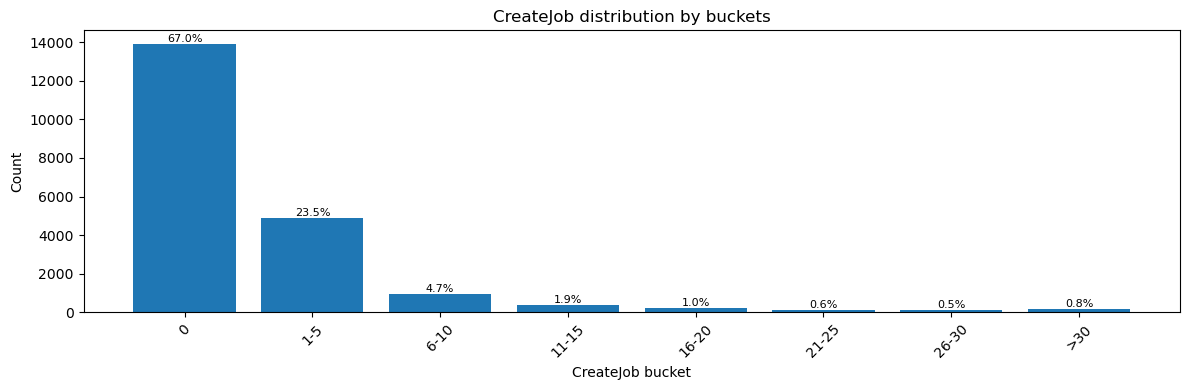

In [ ]:
# CreateJob bucket distribution with explicit zero and missing/invalid buckets
if 'CreateJob' not in df_raw.columns:
    raise ValueError("CreateJob column not found in df_raw")

raw_cj = df_raw['CreateJob'].copy()
raw_str = raw_cj.astype('string').str.strip()

# Separate missing/null from invalid text
is_missing = raw_str.isna() | raw_str.eq('')
cj_num = pd.to_numeric(raw_str, errors='coerce')
is_invalid = (~is_missing) & (cj_num.isna())

# Keep non-negative numeric values for bucketing
cj_num = cj_num.clip(lower=0)

# Increment buckets for positive values
bucket_size = 5
p99 = int(np.nanpercentile(cj_num.dropna(), 99)) if cj_num.notna().any() else 0
upper = max(bucket_size, int(np.ceil(p99 / bucket_size) * bucket_size))
edges = list(range(0, upper + bucket_size, bucket_size))
labels = [f"{a+1}-{b}" for a, b in zip(edges[:-1], edges[1:])]

pos = cj_num.where(cj_num > 0)
pos_bucket = pd.cut(pos, bins=edges, labels=labels, include_lowest=False, right=True)
pos_bucket = pos_bucket.astype('string').fillna('')

bucket = pd.Series(index=df_raw.index, dtype='string')
bucket[is_missing] = 'Missing/Null'
bucket[is_invalid] = 'Invalid'
bucket[(~is_missing) & (~is_invalid) & (cj_num == 0)] = '0'
bucket[(~is_missing) & (~is_invalid) & (cj_num > 0)] = pos_bucket[(~is_missing) & (~is_invalid) & (cj_num > 0)]

# Any value above upper falls into overflow bucket
overflow_mask = (~is_missing) & (~is_invalid) & (cj_num > upper)
if overflow_mask.any():
    bucket[overflow_mask] = f'>{upper}'

# Enforce display order
ordered_levels = ['Missing/Null', 'Invalid', '0'] + labels
if overflow_mask.any():
    ordered_levels.append(f'>{upper}')

dist = bucket.value_counts(dropna=False).reindex(ordered_levels).fillna(0).astype(int)
dist_pct = (dist / len(df_raw) * 100.0).round(2)
bucket_table = pd.DataFrame({'count': dist, 'pct': dist_pct})

print('CreateJob bucket distribution:')
print(bucket_table[bucket_table['count'] > 0])

# Plot only non-empty buckets
plot_table = bucket_table[bucket_table['count'] > 0].copy()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(plot_table.index.astype(str), plot_table['count'].values)
ax.set_title('CreateJob distribution by buckets')
ax.set_xlabel('CreateJob bucket')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for i, (_, row) in enumerate(plot_table.iterrows()):
    ax.text(i, row['count'], f"{row['pct']:.1f}%", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### RetainedJob Bucketing
Mirror the same bucket design for `RetainedJob` so the two job fields can be compared on the same scale.

RetainedJob bucket distribution:
       count    pct
0      10484  50.48
1-5     6977  33.59
6-10    1724   8.30
11-15    630   3.03
16-20    325   1.56
21-25    179   0.86
26-30    123   0.59
31-35     60   0.29
36-40     50   0.24
41-45     44   0.21
>45      172   0.83


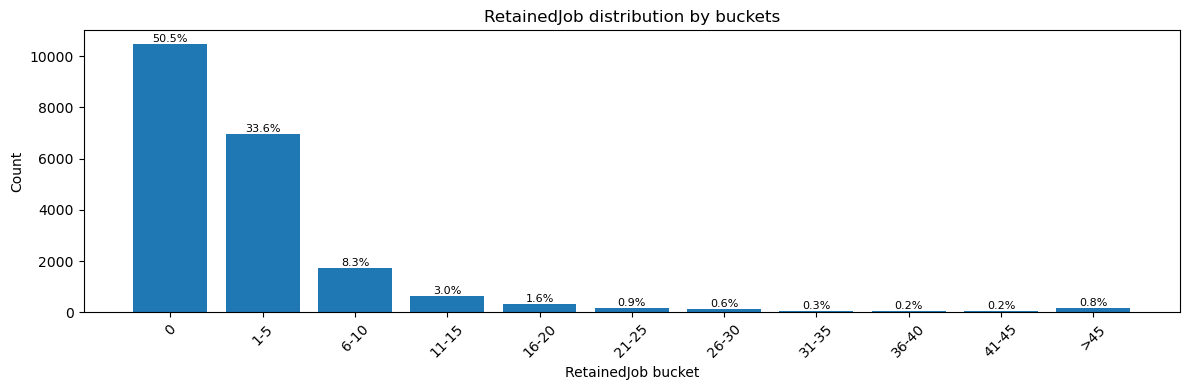

In [ ]:
#  RetainedJob bucket distribution with explicit zero and missing/invalid buckets
if 'RetainedJob' not in df_raw.columns:
    raise ValueError('RetainedJob column not found in df_raw')

raw_rj = df_raw['RetainedJob'].copy()
raw_str = raw_rj.astype('string').str.strip()

# Separate missing/null from invalid text
is_missing = raw_str.isna() | raw_str.eq('')
rj_num = pd.to_numeric(raw_str, errors='coerce')
is_invalid = (~is_missing) & (rj_num.isna())

# Keep non-negative numeric values for bucketing
rj_num = rj_num.clip(lower=0)

# Increment buckets for positive values
bucket_size = 5
p99 = int(np.nanpercentile(rj_num.dropna(), 99)) if rj_num.notna().any() else 0
upper = max(bucket_size, int(np.ceil(p99 / bucket_size) * bucket_size))
edges = list(range(0, upper + bucket_size, bucket_size))
labels = [f"{a+1}-{b}" for a, b in zip(edges[:-1], edges[1:])]

pos = rj_num.where(rj_num > 0)
pos_bucket = pd.cut(pos, bins=edges, labels=labels, include_lowest=False, right=True)
pos_bucket = pos_bucket.astype('string').fillna('')

bucket = pd.Series(index=df_raw.index, dtype='string')
bucket[is_missing] = 'Missing/Null'
bucket[is_invalid] = 'Invalid'
bucket[(~is_missing) & (~is_invalid) & (rj_num == 0)] = '0'
bucket[(~is_missing) & (~is_invalid) & (rj_num > 0)] = pos_bucket[(~is_missing) & (~is_invalid) & (rj_num > 0)]

# Any value above upper falls into overflow bucket
overflow_mask = (~is_missing) & (~is_invalid) & (rj_num > upper)
if overflow_mask.any():
    bucket[overflow_mask] = f'>{upper}'

# Enforce display order
ordered_levels = ['Missing/Null', 'Invalid', '0'] + labels
if overflow_mask.any():
    ordered_levels.append(f'>{upper}')

dist = bucket.value_counts(dropna=False).reindex(ordered_levels).fillna(0).astype(int)
dist_pct = (dist / len(df_raw) * 100.0).round(2)
bucket_table = pd.DataFrame({'count': dist, 'pct': dist_pct})

print('RetainedJob bucket distribution:')
print(bucket_table[bucket_table['count'] > 0])

# Plot only non-empty buckets
plot_table = bucket_table[bucket_table['count'] > 0].copy()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(plot_table.index.astype(str), plot_table['count'].values)
ax.set_title('RetainedJob distribution by buckets')
ax.set_xlabel('RetainedJob bucket')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for i, (_, row) in enumerate(plot_table.iterrows()):
    ax.text(i, row['count'], f"{row['pct']:.1f}%", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### CreateJob by Outcome
Split the `CreateJob` buckets by accepted versus denied applications to show where the target separation is strongest.

CreateJob bucket split (Accepted vs Denied):
Accept            Denied  Accepted  n_total  accept_rate  deny_rate
CreateJob_bucket                                                   
0                   2785     11134    13919       0.7999     0.2001
1-5                 1679      3209     4888       0.6565     0.3435
6-10                 174       795      969       0.8204     0.1796
11-15                 49       335      384       0.8724     0.1276
16-20                 26       188      214       0.8785     0.1215
21-25                  6       123      129       0.9535     0.0465
26-30                  6        87       93       0.9355     0.0645
>30                   24       148      172       0.8605     0.1395


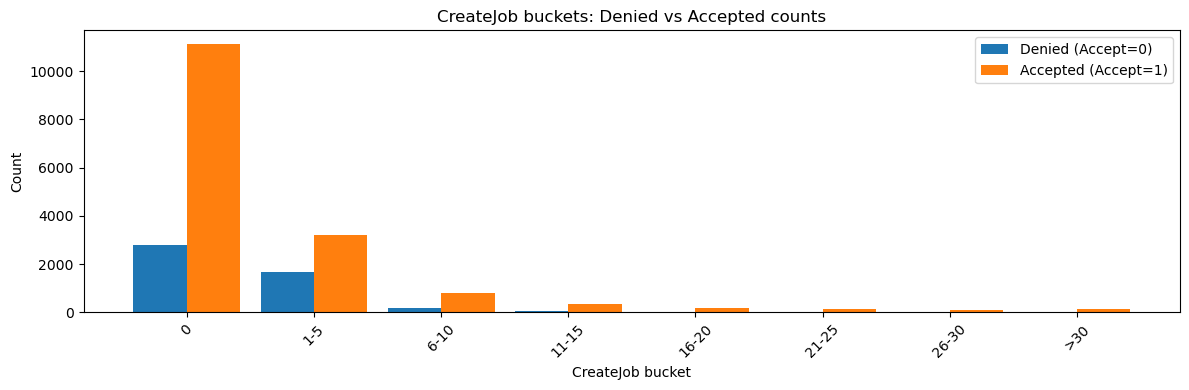

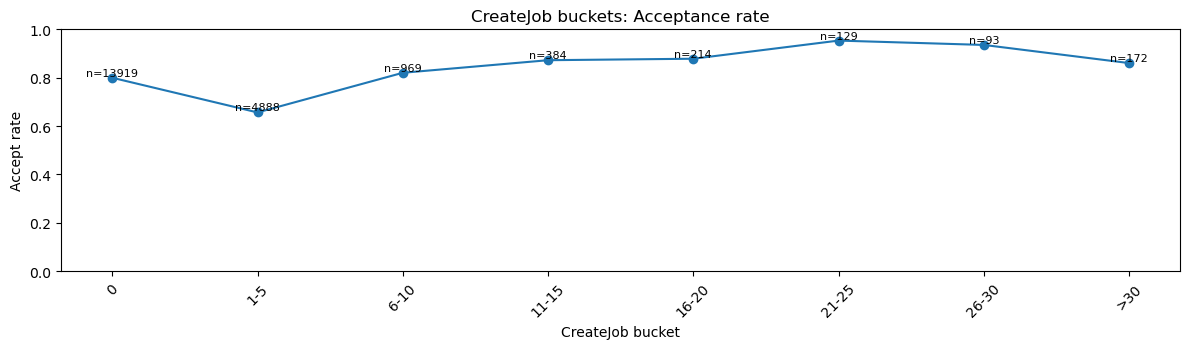

In [ ]:
# Cell 10: CreateJob buckets split by Accepted vs Denied
if not {'CreateJob', 'Accept'}.issubset(df_raw.columns):
    raise ValueError("Expected columns CreateJob and Accept in df_raw")

raw_cj = df_raw['CreateJob'].astype('string').str.strip()
accept_num = pd.to_numeric(df_raw['Accept'], errors='coerce')

is_missing = raw_cj.isna() | raw_cj.eq('')
cj_num = pd.to_numeric(raw_cj, errors='coerce')
is_invalid = (~is_missing) & cj_num.isna()
cj_num = cj_num.clip(lower=0)

# Same bucket strategy used before: explicit zero + missing/invalid + increments
bucket_size = 5
p99 = int(np.nanpercentile(cj_num.dropna(), 99)) if cj_num.notna().any() else 0
upper = max(bucket_size, int(np.ceil(p99 / bucket_size) * bucket_size))
edges = list(range(0, upper + bucket_size, bucket_size))
labels = [f"{a+1}-{b}" for a, b in zip(edges[:-1], edges[1:])]

bucket = pd.Series(index=df_raw.index, dtype='string')
bucket[is_missing] = 'Missing/Null'
bucket[is_invalid] = 'Invalid'
bucket[(~is_missing) & (~is_invalid) & (cj_num == 0)] = '0'

pos = cj_num.where(cj_num > 0)
pos_bucket = pd.cut(pos, bins=edges, labels=labels, include_lowest=False, right=True)
bucket[(~is_missing) & (~is_invalid) & (cj_num > 0)] = pos_bucket[(~is_missing) & (~is_invalid) & (cj_num > 0)].astype('string')

overflow_mask = (~is_missing) & (~is_invalid) & (cj_num > upper)
if overflow_mask.any():
    bucket[overflow_mask] = f'>{upper}'

ordered_levels = ['Missing/Null', 'Invalid', '0'] + labels
if overflow_mask.any():
    ordered_levels.append(f'>{upper}')

df_split = pd.DataFrame({
    'CreateJob_bucket': bucket,
    'Accept': accept_num,
}).dropna(subset=['CreateJob_bucket', 'Accept']).copy()
df_split['Accept'] = df_split['Accept'].astype(int)

# Count split table: rows=bucket, cols=Denied(0)/Accepted(1)
split_counts = pd.crosstab(df_split['CreateJob_bucket'], df_split['Accept']).reindex(ordered_levels).fillna(0).astype(int)
split_counts = split_counts.rename(columns={0: 'Denied', 1: 'Accepted'})
split_counts = split_counts[split_counts.sum(axis=1) > 0]

split_rates = split_counts.copy()
split_rates['accept_rate'] = (split_counts['Accepted'] / split_counts.sum(axis=1)).round(4)
split_rates['deny_rate'] = (split_counts['Denied'] / split_counts.sum(axis=1)).round(4)
split_rates['n_total'] = split_counts.sum(axis=1)

print('CreateJob bucket split (Accepted vs Denied):')
print(split_rates[['Denied', 'Accepted', 'n_total', 'accept_rate', 'deny_rate']])

# Plot grouped bars by bucket
x = np.arange(len(split_counts.index))
w = 0.42
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w/2, split_counts['Denied'].values, width=w, label='Denied (Accept=0)')
ax.bar(x + w/2, split_counts['Accepted'].values, width=w, label='Accepted (Accept=1)')
ax.set_xticks(x)
ax.set_xticklabels(split_counts.index.astype(str), rotation=45)
ax.set_title('CreateJob buckets: Denied vs Accepted counts')
ax.set_xlabel('CreateJob bucket')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

# Optional: acceptance rate line by bucket
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(split_rates.index.astype(str), split_rates['accept_rate'], marker='o')
ax.set_ylim(0, 1)
ax.set_title('CreateJob buckets: Acceptance rate')
ax.set_xlabel('CreateJob bucket')
ax.set_ylabel('Accept rate')
ax.tick_params(axis='x', rotation=45)
for i, (_, row) in enumerate(split_rates.iterrows()):
    ax.text(i, row['accept_rate'], f"n={int(row['n_total'])}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### RetainedJob by Outcome
Apply the same accepted-versus-denied split to `RetainedJob` so its bucketed signal is directly comparable with `CreateJob`.

RetainedJob bucket split (Accepted vs Denied):
Accept              Denied  Accepted  n_total  accept_rate  deny_rate
RetainedJob_bucket                                                   
0                     1316      9168    10484       0.8745     0.1255
1-5                   2474      4503     6977       0.6454     0.3546
6-10                   587      1137     1724       0.6595     0.3405
11-15                  164       466      630       0.7397     0.2603
16-20                   72       253      325       0.7785     0.2215
21-25                   43       136      179       0.7598     0.2402
26-30                   26        97      123       0.7886     0.2114
31-35                   14        46       60       0.7667     0.2333
36-40                    7        43       50       0.8600     0.1400
41-45                   11        33       44       0.7500     0.2500
>45                     35       137      172       0.7965     0.2035


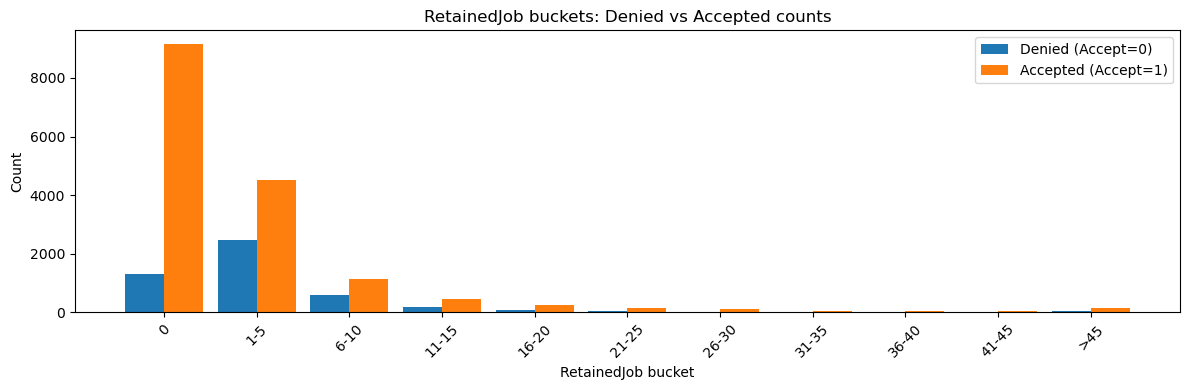

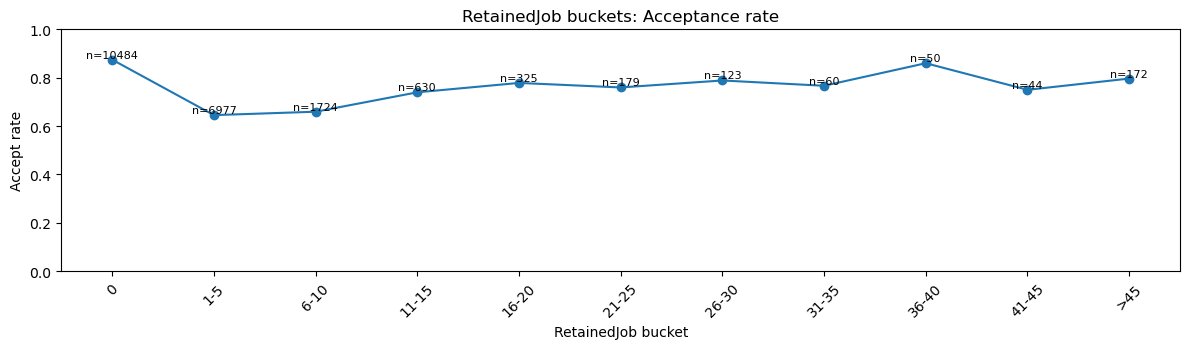

In [ ]:
# Cell 11: RetainedJob buckets split by Accepted vs Denied
if not {'RetainedJob', 'Accept'}.issubset(df_raw.columns):
    raise ValueError("Expected columns RetainedJob and Accept in df_raw")

raw_rj = df_raw['RetainedJob'].astype('string').str.strip()
accept_num = pd.to_numeric(df_raw['Accept'], errors='coerce')

is_missing = raw_rj.isna() | raw_rj.eq('')
rj_num = pd.to_numeric(raw_rj, errors='coerce')
is_invalid = (~is_missing) & rj_num.isna()
rj_num = rj_num.clip(lower=0)

# Same bucket strategy: explicit zero + missing/invalid + increments
bucket_size = 5
p99 = int(np.nanpercentile(rj_num.dropna(), 99)) if rj_num.notna().any() else 0
upper = max(bucket_size, int(np.ceil(p99 / bucket_size) * bucket_size))
edges = list(range(0, upper + bucket_size, bucket_size))
labels = [f"{a+1}-{b}" for a, b in zip(edges[:-1], edges[1:])]

bucket = pd.Series(index=df_raw.index, dtype='string')
bucket[is_missing] = 'Missing/Null'
bucket[is_invalid] = 'Invalid'
bucket[(~is_missing) & (~is_invalid) & (rj_num == 0)] = '0'

pos = rj_num.where(rj_num > 0)
pos_bucket = pd.cut(pos, bins=edges, labels=labels, include_lowest=False, right=True)
bucket[(~is_missing) & (~is_invalid) & (rj_num > 0)] = pos_bucket[(~is_missing) & (~is_invalid) & (rj_num > 0)].astype('string')

overflow_mask = (~is_missing) & (~is_invalid) & (rj_num > upper)
if overflow_mask.any():
    bucket[overflow_mask] = f'>{upper}'

ordered_levels = ['Missing/Null', 'Invalid', '0'] + labels
if overflow_mask.any():
    ordered_levels.append(f'>{upper}')

df_split = pd.DataFrame({
    'RetainedJob_bucket': bucket,
    'Accept': accept_num,
}).dropna(subset=['RetainedJob_bucket', 'Accept']).copy()
df_split['Accept'] = df_split['Accept'].astype(int)

# Count split table: rows=bucket, cols=Denied(0)/Accepted(1)
split_counts = pd.crosstab(df_split['RetainedJob_bucket'], df_split['Accept']).reindex(ordered_levels).fillna(0).astype(int)
split_counts = split_counts.rename(columns={0: 'Denied', 1: 'Accepted'})
split_counts = split_counts[split_counts.sum(axis=1) > 0]

split_rates = split_counts.copy()
split_rates['accept_rate'] = (split_counts['Accepted'] / split_counts.sum(axis=1)).round(4)
split_rates['deny_rate'] = (split_counts['Denied'] / split_counts.sum(axis=1)).round(4)
split_rates['n_total'] = split_counts.sum(axis=1)

print('RetainedJob bucket split (Accepted vs Denied):')
print(split_rates[['Denied', 'Accepted', 'n_total', 'accept_rate', 'deny_rate']])

# Plot grouped bars by bucket
x = np.arange(len(split_counts.index))
w = 0.42
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w/2, split_counts['Denied'].values, width=w, label='Denied (Accept=0)')
ax.bar(x + w/2, split_counts['Accepted'].values, width=w, label='Accepted (Accept=1)')
ax.set_xticks(x)
ax.set_xticklabels(split_counts.index.astype(str), rotation=45)
ax.set_title('RetainedJob buckets: Denied vs Accepted counts')
ax.set_xlabel('RetainedJob bucket')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

# Optional: acceptance rate line by bucket
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(split_rates.index.astype(str), split_rates['accept_rate'], marker='o')
ax.set_ylim(0, 1)
ax.set_title('RetainedJob buckets: Acceptance rate')
ax.set_xlabel('RetainedJob bucket')
ax.set_ylabel('Accept rate')
ax.tick_params(axis='x', rotation=45)
for i, (_, row) in enumerate(split_rates.iterrows()):
    ax.text(i, row['accept_rate'], f"n={int(row['n_total'])}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### High-Cardinality Categories in  `Bank` and `City`
Evaluate simple bucketing strategies for `Bank` and `City` so the notebook ends with practical encoding guidance for downstream models.

Bank encoding diagnostics
Rows: 20,768 | Unique categories: 497
Top frequency categories:
                                count   share
Bank                                         
JPMORGAN CHASE BANK NATL ASSOC   3027  0.1458
PNC BANK, NATIONAL ASSOCIATION   1352  0.0651
BBCN BANK                        1352  0.0651
CITIZENS BANK NATL ASSOC         1326  0.0638
U.S. BANK NATIONAL ASSOCIATION   1294  0.0623
BMO HARRIS BK NATL ASSOC          714  0.0344
SMALL BUS. GROWTH CORP            668  0.0322
BANK OF AMERICA NATL ASSOC        628  0.0302
SOMERCOR 504, INC.                573  0.0276
CAPITAL ONE NATL ASSOC            552  0.0266
BANCO POPULAR NORTH AMERICA       428  0.0206
WELLS FARGO BANK NATL ASSOC       404  0.0195
FIFTH THIRD BANK                  387  0.0186
URBAN PARTNERSHIP BANK            378  0.0182
BUSEY BANK                        361  0.0174
UNION NATIONAL BANK               263  0.0127
CITIBANK, N.A.                    260  0.0125
HEARTLAND BK & TR CO              25

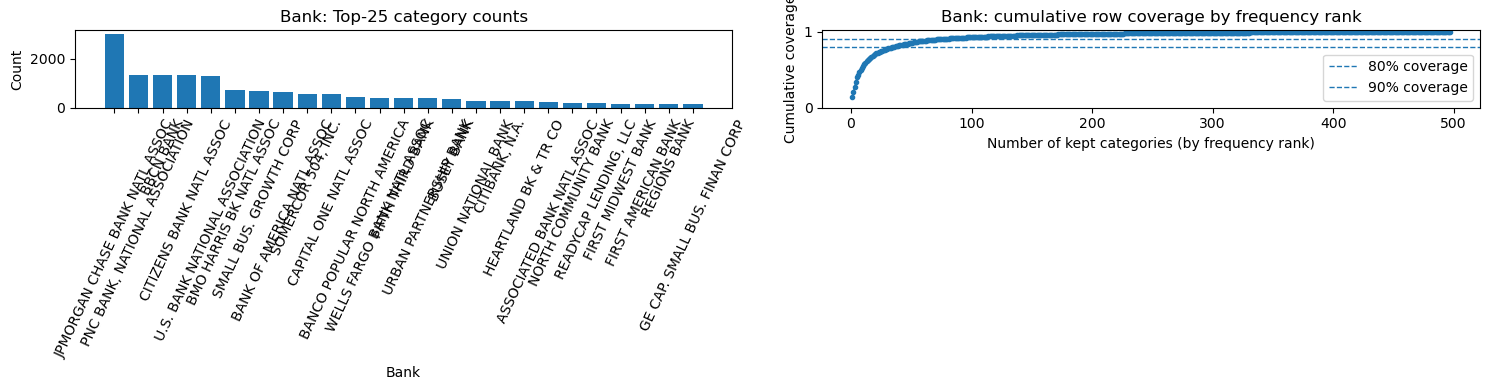


Acceptance-rate table for recommended strategy (top 20 groups by size):
                                   n    rate
enc                                         
JPMORGAN CHASE BANK NATL ASSOC  3027  0.7060
OTHER                           2644  0.8048
PNC BANK, NATIONAL ASSOCIATION  1352  0.7175
BBCN BANK                       1352  0.5629
CITIZENS BANK NATL ASSOC        1326  0.5626
U.S. BANK NATIONAL ASSOCIATION  1294  0.7790
BMO HARRIS BK NATL ASSOC         714  0.9398
SMALL BUS. GROWTH CORP           668  1.0000
BANK OF AMERICA NATL ASSOC       628  0.6911
SOMERCOR 504, INC.               573  1.0000
CAPITAL ONE NATL ASSOC           552  0.5851
BANCO POPULAR NORTH AMERICA      428  0.7033
WELLS FARGO BANK NATL ASSOC      404  0.8045
FIFTH THIRD BANK                 387  0.8320
URBAN PARTNERSHIP BANK           378  0.8598
BUSEY BANK                       361  0.9529
UNION NATIONAL BANK              263  0.9240
CITIBANK, N.A.                   260  0.8269
HEARTLAND BK & TR CO       

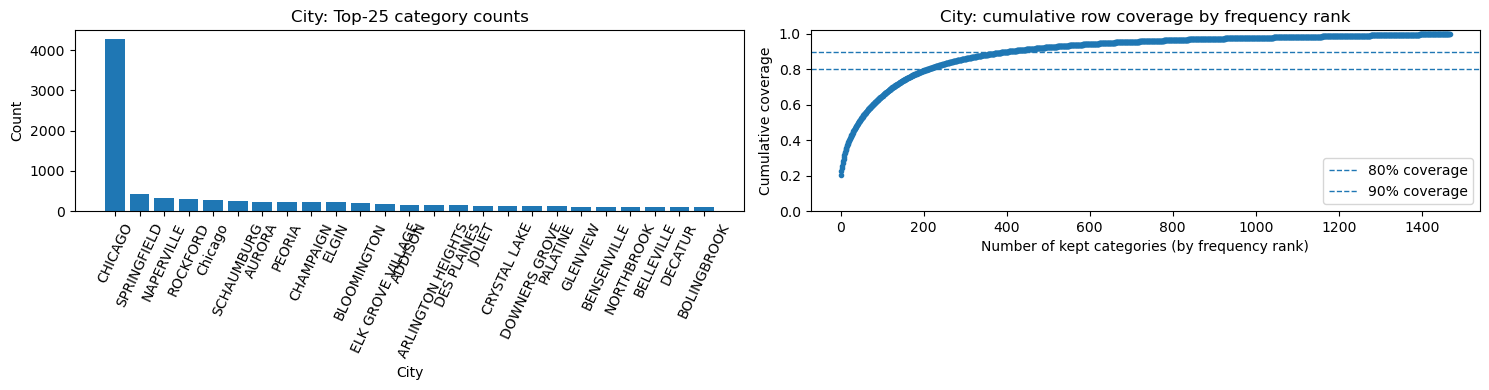


Acceptance-rate table for recommended strategy (top 20 groups by size):
                      n    rate
enc                            
OTHER              9890  0.7796
CHICAGO            4280  0.7180
SPRINGFIELD         433  0.8453
NAPERVILLE          320  0.7812
ROCKFORD            309  0.8835
Chicago             282  0.6844
SCHAUMBURG          259  0.7297
AURORA              235  0.8085
PEORIA              229  0.8210
CHAMPAIGN           216  0.9167
ELGIN               215  0.7860
BLOOMINGTON         191  0.8377
ELK GROVE VILLAGE   182  0.8187
ADDISON             150  0.8800
ARLINGTON HEIGHTS   144  0.7569
DES PLAINES         141  0.6454
JOLIET              136  0.7941
DOWNERS GROVE       129  0.7442
CRYSTAL LAKE        129  0.8062
PALATINE            118  0.8220

Practical encoding rule: keep frequent categories from the recommended strategy, map the rest to OTHER.
For trees, integer/frequency encoding of kept categories + OTHER often works well.
For linear/SVM models, use one-hot 

In [ ]:
# Cell 13: Bank/City encoding diagnostics for high-frequency bucketing
if not {'Bank', 'City', 'Accept'}.issubset(df_raw.columns):
    missing_cols = [c for c in ['Bank', 'City', 'Accept'] if c not in df_raw.columns]
    raise ValueError(f"Missing expected columns in df_raw: {missing_cols}")

target = pd.to_numeric(df_raw['Accept'], errors='coerce')
df_cat = pd.DataFrame({
    'Bank': df_raw['Bank'].astype('string').str.strip(),
    'City': df_raw['City'].astype('string').str.strip(),
    'Accept': target,
})

# Normalize null-like tokens
for col in ['Bank', 'City']:
    s = df_cat[col]
    s = s.fillna('MISSING')
    s = s.replace({'': 'MISSING', 'nan': 'MISSING', 'None': 'MISSING', '<NA>': 'MISSING'})
    df_cat[col] = s

df_cat = df_cat.dropna(subset=['Accept']).copy()
df_cat['Accept'] = df_cat['Accept'].astype(int)

def evaluate_bucketing(cat_series: pd.Series, y: pd.Series, mode: str, value: int) -> dict:
    counts = cat_series.value_counts(dropna=False)
    if mode == 'top_k':
        keep = set(counts.head(value).index)
        label = f'top_{value}'
    elif mode == 'min_count':
        keep = set(counts[counts >= value].index)
        label = f'min_count_{value}'
    else:
        raise ValueError("mode must be 'top_k' or 'min_count'")

    encoded = cat_series.where(cat_series.isin(keep), 'OTHER')
    tmp = pd.DataFrame({'enc': encoded, 'y': y})
    grp = tmp.groupby('enc').agg(n=('y', 'size'), rate=('y', 'mean')).sort_values('n', ascending=False)

    n_total = int(len(tmp))
    n_other = int(grp.loc['OTHER', 'n']) if 'OTHER' in grp.index else 0
    other_share = n_other / n_total if n_total else np.nan
    n_groups = int(len(grp))
    min_group_n = int(grp['n'].min()) if len(grp) else 0
    global_rate = float(tmp['y'].mean()) if n_total else np.nan
    weight = grp['n'] / n_total if n_total else 0.0
    weighted_signal = float(np.sqrt(np.sum(weight * (grp['rate'] - global_rate) ** 2))) if n_total else np.nan

    return {
        'strategy': label,
        'mode': mode,
        'value': value,
        'n_groups': n_groups,
        'other_share': other_share,
        'min_group_n': min_group_n,
        'weighted_signal': weighted_signal,
        'group_table': grp,
    }

def pick_recommendation(results: list) -> dict:
    # Prefer practical mappings: not too sparse, not too much collapsed into OTHER.
    feasible = [
        r for r in results
        if r['min_group_n'] >= 50 and r['other_share'] <= 0.50 and r['n_groups'] <= 60
    ]
    pool = feasible if feasible else results
    pool = sorted(pool, key=lambda r: (-r['weighted_signal'], r['n_groups'], r['other_share']))
    return pool[0]

def analyze_feature(col: str):
    s = df_cat[col]
    y = df_cat['Accept']

    freq = s.value_counts(dropna=False)
    cum = (freq.cumsum() / len(s)).rename('cum_share')
    top_n = min(25, len(freq))

    print('=' * 90)
    print(f'{col} encoding diagnostics')
    print(f'Rows: {len(s):,} | Unique categories: {s.nunique(dropna=False):,}')
    print('Top frequency categories:')
    print((freq.head(top_n).to_frame('count').assign(share=lambda d: (d['count'] / len(s)).round(4))))
    print('\nCoverage checkpoints:')
    for k in [5, 10, 20, 50, 100]:
        if k <= len(freq):
            print(f'  Top-{k:>3}: {(freq.head(k).sum() / len(s)) * 100:6.2f}% of rows')

    candidates = []
    for k in [5, 10, 20, 30, 50, 80, 120]:
        if k <= len(freq):
            candidates.append(evaluate_bucketing(s, y, mode='top_k', value=k))
    for m in [20, 50, 100, 200, 500, 1000]:
        candidates.append(evaluate_bucketing(s, y, mode='min_count', value=m))

    summary = pd.DataFrame([{
        'strategy': r['strategy'],
        'n_groups': r['n_groups'],
        'other_share_pct': 100.0 * r['other_share'],
        'min_group_n': r['min_group_n'],
        'weighted_signal': r['weighted_signal'],
    } for r in candidates]).sort_values(['weighted_signal', 'n_groups'], ascending=[False, True])

    print('\nCandidate strategy comparison (higher weighted_signal is better):')
    print(summary.round(4).to_string(index=False))

    best = pick_recommendation(candidates)
    print('\nRecommended bucketing:')
    print(f"  {best['strategy']}  | groups={best['n_groups']} | OTHER={best['other_share']*100:.2f}% | min_group_n={best['min_group_n']}")
    print('  Reason: balances signal strength with fewer sparse buckets.')

    # Plot 1: frequency of top categories
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].bar(freq.head(top_n).index.astype(str), freq.head(top_n).values)
    axes[0].set_title(f'{col}: Top-{top_n} category counts')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=65)

    # Plot 2: cumulative coverage curve
    x = np.arange(1, len(freq) + 1)
    axes[1].plot(x, cum.values, marker='.', linewidth=1)
    axes[1].axhline(0.80, linestyle='--', linewidth=1, label='80% coverage')
    axes[1].axhline(0.90, linestyle='--', linewidth=1, label='90% coverage')
    axes[1].set_title(f'{col}: cumulative row coverage by frequency rank')
    axes[1].set_xlabel('Number of kept categories (by frequency rank)')
    axes[1].set_ylabel('Cumulative coverage')
    axes[1].set_ylim(0, 1.02)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    # Show acceptance rate table for selected strategy
    print('\nAcceptance-rate table for recommended strategy (top 20 groups by size):')
    print(best['group_table'].head(20).round(4))

for feature_name in ['Bank', 'City']:
    analyze_feature(feature_name)

print('\nPractical encoding rule: keep frequent categories from the recommended strategy, map the rest to OTHER.')
print('For trees, integer/frequency encoding of kept categories + OTHER often works well.')
print('For linear/SVM models, use one-hot on kept categories + OTHER to avoid ordinal artifacts.')